<a href="https://colab.research.google.com/github/SachiniSiriwardene/Airline-Delay-Analysis/blob/main/Copy_of_Full_Code_Airline_Delay_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Airlines operate in a complex and time-sensitive environment where punctuality has a direct impact on profitability and customer trust. Flight delays, cancellations, and diversions create cascading effects that disrupt schedules, increase operational cost, and reduce passenger satisfaction. Maintaining reliability and efficiency is crucial for sustaining competitiveness and protecting brand reputation in the aviation industry.

To improve performance, airlines continuously analyze operational data that captures flight activities, disruption patterns, and the causes of delays. Understanding how factors such as carrier operations, seasonal variation, and airport performance influence on time arrivals enables data-driven decision making for better control of delays and disruptions.

By leveraging these insights, airlines identify root causes of inefficiency, optimize scheduling, allocate resources strategically, and minimize the financial and service impact of delays. This approach lowers operational costs, enhances passenger experience, and strengthens overall reliability.

## **Objective**

The objective is to identify patterns and key factors contributing to flight delays, cancellations, and diversions. By uncovering operational drivers of disruption, the goal is to enable targeted improvements in scheduling, planning, and resource management that enhance reliability, reduce cost, and improve overall service quality.

## **Data Dictionary**

| Column Name             | Description |
|--------------------------|--------------|
| **year**                 | The year of the data record |
| **month**                | The month of the data record |
| **carrier**              | carrier (airline) code |
| **airport**              | airport code representing the airport |
| **arr_flights**          | Total number of arriving flights for the given carrier and airport during the month |
| **arr_del15**            | Number of arriving flights delayed by 15 minutes or more |
| **carrier_ct**           | Count of arrival delays attributed to carrier-related issues (e.g., maintenance, crew problems) |
| **weather_ct**           | Count of arrival delays attributed to weather conditions |
| **nas_ct**               | Count of arrival delays attributed to the National Airspace System (e.g., air traffic control, volume) |
| **security_ct**          | Count of arrival delays attributed to security-related issues |
| **late_aircraft_ct**     | Count of arrival delays attributed to late-arriving aircraft from a previous flight |
| **arr_cancelled**        | Number of flights canceled during the period |
| **arr_diverted**         | Number of flights diverted to another airport during the period |
| **arr_delay**            | Total minutes of arrival delay across all flights in the group |
| **carrier_delay**        | Total minutes of delay attributed to the carrier |
| **weather_delay**        | Total minutes of delay attributed to weather conditions |
| **nas_delay**            | Total minutes of delay attributed to the National Airspace System |
| **security_delay**       | Total minutes of delay attributed to security issues |
| **late_aircraft_delay**  | Total minutes of delay attributed to late-arriving aircraft from a previous flight |


**Note :**

- A flight is considered delayed when it arrived 15 or more minutes than the schedule. Delayed minutes are calculated for delayed flights only.
- When multiple causes are assigned to one delayed flight, each cause is prorated based on delayed minutes it is responsible for. The displayed numbers are rounded and may not add up to the total.

# **Requirements**

In order to meet the objectives, we identify a set of questions we need to answer.

### 1. Does the average arrival delay differ between high-traffic airports and low-traffic airports?

Understanding whether high-traffic airports experience systematically higher or lower arrival delays helps airlines benchmark operational efficiency and identify whether airport congestion or infrastructure capacity contributes to overall delay patterns.

---

### 2. Is the average number of flights cancelled associated with weather-related delays across airports?

Examining whether airports experiencing weather-related delays have a higher average number of cancelled flights helps determine how significantly weather impacts operations and identifies which airports are more vulnerable to weather-related disruptions.

---

### 3. Is a flight’s cancellation status (Yes/No) associated with the origin airport for a sample of four airports?

Examining whether flights departing from certain airports are more likely to be cancelled helps identify if airport-specific factors such as infrastructure, weather patterns, or operational constraints contribute to higher disruption rates.

---

### 4. Does the average delay caused by late-arriving aircraft differ between months of the year?

Assessing whether late-arriving-aircraft delays vary seasonally helps schedule planners embed more buffer time or adjust frequencies in months with higher propagation risk.

---


### 5. Does the average carrier-related delay minutes differ across a sample of four origin airports?

Analyzing whether the average carrier-related delay minutes vary among a representative sample of four origin airports helps identify location-specific operational inefficiencies. This focused comparison enables targeted improvements in crew management, maintenance scheduling, and other carrier-related operations.

---

### 6. Does the average number of flights delayed more than 15 minutes differ across seasons?

Analyzing seasonal variation in the count of significant delays (>15 min) uncovers temporal patterns that can guide resource allocation, staffing, and schedule-adjustment decisions throughout the year.

# **Operationalize**



```
# This is formatted as code
```

Now that we have clearly defined our requirements, the next step is to work with the data and transform it in a way that makes it suitable for meaningful analysis.

This involves preparing the raw data to ensure it is clean, consistent, and structured in alignment with the business objectives. The process includes handling missing values, correcting inconsistencies, engineering relevant features, and validating data quality. These transformations are critical because well-prepared data forms the foundation for accurate insights and sound decision-making in the later stages of analysis.

By operationalizing the data effectively, we ensure that the dataset reflects the real-world context of the problem and supports reliable, data-driven conclusions.

# **Installing and Importing the Necessary Libraries**

In [5]:
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.0 -q

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [6]:
# To load and manipulate data
import pandas as pd
import numpy as np
from IPython.display import display

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# For hypothesis testing
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, shapiro, levene

# **Loading the Data**

In [7]:
from google.colab import drive
drive.mount('/content/drive')
airplane_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Airline_Delay_Dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Overview**

In [8]:
airplane_df.head(5)

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,CE-000,AT-00,89.0,13.0,2.25,1.60,3.16,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,CE-000,AT-01,62.0,10.0,1.97,0.04,0.57,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,CE-000,AT-02,62.0,10.0,2.73,1.18,1.80,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,CE-000,AT-03,66.0,12.0,3.69,2.27,4.47,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,CE-000,AT-04,92.0,22.0,7.76,0.00,2.96,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [9]:
airplane_df.tail(5)

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
92472,2019,1,CE-008,AT-77,195.0,68.0,12.12,1.87,17.97,0.0,36.04,22.0,0.0,4138.0,603.0,196.0,780.0,0.0,2559.0
92473,2019,1,CE-008,AT-78,52.0,14.0,2.74,0.69,2.46,0.0,8.11,2.0,1.0,726.0,323.0,31.0,112.0,0.0,260.0
92474,2019,1,CE-008,AT-79,106.0,26.0,4.67,2.26,11.81,0.0,7.26,17.0,0.0,1259.0,313.0,99.0,484.0,0.0,363.0
92475,2019,1,CE-008,AT-80,116.0,35.0,6.83,6.92,11.50,0.0,9.75,22.0,0.0,2307.0,474.0,633.0,523.0,0.0,677.0
92476,2019,1,CE-008,AT-148,26.0,4.0,1.16,0.64,1.92,0.0,0.29,5.0,0.0,120.0,50.0,14.0,41.0,0.0,15.0


In [10]:
airplane_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92477 entries, 0 to 92476
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 92477 non-null  int64  
 1   month                92477 non-null  int64  
 2   carrier              92477 non-null  object 
 3   airport              92477 non-null  object 
 4   arr_flights          92326 non-null  float64
 5   arr_del15            92139 non-null  float64
 6   carrier_ct           92326 non-null  float64
 7   weather_ct           92326 non-null  float64
 8   nas_ct               92326 non-null  float64
 9   security_ct          92326 non-null  float64
 10  late_aircraft_ct     92326 non-null  float64
 11  arr_cancelled        92326 non-null  float64
 12  arr_diverted         92326 non-null  float64
 13  arr_delay            92326 non-null  float64
 14  carrier_delay        92326 non-null  float64
 15  weather_delay        92326 non-null 

In [11]:
(airplane_df.isnull().sum()/len(airplane_df))*100


,0
year,0.000000
month,0.000000
carrier,0.000000
airport,0.000000
arr_flights,0.163284
arr_del15,0.365496
carrier_ct,0.163284
weather_ct,0.163284
nas_ct,0.163284
security_ct,0.163284


Except for year, month, carrier and airport other columns have null values. The number of arriving flights delayed by 15 minutes or more has the most percentage of null values.

In [12]:
airplane_df.shape
airplane_df.duplicated().sum()

np.int64(0)

There are no duplicated values.

In [13]:
airplane_df.describe().T
# airplane_df.groupby('airport').describe()

,count,mean,std,min,25%,50%,75%,max
year,92477.0,2020.830661,1.355159,2019.0,2020.00,2021.00,2022.00,2023.00
month,92477.0,6.227246,3.397030,1.0,3.00,6.00,9.00,12.00
arr_flights,92326.0,286.671393,910.705200,-21194.0,31.00,82.00,202.00,21873.00
arr_del15,92139.0,56.781797,164.614120,0.0,5.00,14.00,38.00,4142.00
carrier_ct,92326.0,19.492678,51.277935,0.0,1.91,5.31,15.00,1293.91
weather_ct,92326.0,2.140265,7.486700,0.0,0.00,0.27,1.75,266.42
nas_ct,92326.0,15.418681,52.716249,0.0,0.62,2.94,8.97,1485.82
security_ct,92326.0,0.175466,0.825821,0.0,0.00,0.00,0.00,58.69
late_aircraft_ct,92326.0,19.439746,64.820558,0.0,0.94,3.65,11.82,2069.07
arr_cancelled,92326.0,8.404144,53.407028,0.0,0.00,1.00,4.00,4951.00


The no. of arriving flights at some air ports shows a negative value, which should be fixed.
The data type of year & date should be changed to categorical variable.
Most of the delay causes shore a right skewed distirbution with a median higher than the mean which might be caused by extreme maximum values for some months.

# **Data Preprocessing & Feature Engineering**

## Data Preprocessing

### Addressing Inconsistent Values

In [14]:
airplane_df['arr_flights'] = airplane_df['arr_flights'].abs()


In [15]:
airplane_df.tail(10)

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
92467,2019,1,CE-008,AT-72,261.0,82.0,11.59,3.76,26.62,0.00,40.03,12.0,0.0,4068.0,494.0,119.0,907.0,0.0,2548.0
92468,2019,1,CE-008,AT-143,125.0,21.0,4.67,0.57,9.17,0.00,6.60,0.0,0.0,819.0,216.0,13.0,237.0,0.0,353.0
92469,2019,1,CE-008,AT-73,49.0,17.0,1.00,1.83,11.47,0.00,2.70,7.0,0.0,712.0,86.0,61.0,433.0,0.0,132.0
92470,2019,1,CE-008,AT-74,50.0,18.0,6.38,0.38,3.24,0.00,8.00,2.0,0.0,902.0,332.0,31.0,69.0,0.0,470.0
92471,2019,1,CE-008,AT-76,252.0,78.0,14.11,0.00,26.25,0.13,37.50,6.0,0.0,4495.0,755.0,0.0,990.0,10.0,2740.0
92472,2019,1,CE-008,AT-77,195.0,68.0,12.12,1.87,17.97,0.00,36.04,22.0,0.0,4138.0,603.0,196.0,780.0,0.0,2559.0
92473,2019,1,CE-008,AT-78,52.0,14.0,2.74,0.69,2.46,0.00,8.11,2.0,1.0,726.0,323.0,31.0,112.0,0.0,260.0
92474,2019,1,CE-008,AT-79,106.0,26.0,4.67,2.26,11.81,0.00,7.26,17.0,0.0,1259.0,313.0,99.0,484.0,0.0,363.0
92475,2019,1,CE-008,AT-80,116.0,35.0,6.83,6.92,11.50,0.00,9.75,22.0,0.0,2307.0,474.0,633.0,523.0,0.0,677.0
92476,2019,1,CE-008,AT-148,26.0,4.0,1.16,0.64,1.92,0.00,0.29,5.0,0.0,120.0,50.0,14.0,41.0,0.0,15.0


In [16]:
airplane_df['year'] = airplane_df['year'].astype('category')
print(airplane_df['year'].dtype)

category


In [17]:
airplane_df['month'] = airplane_df['month'].astype('category')
print(airplane_df['month'].dtype)
airplane_df.describe().T


category


,count,mean,std,min,25%,50%,75%,max
arr_flights,92326.0,318.223848,900.165443,1.0,39.00,88.00,214.00,21873.00
arr_del15,92139.0,56.781797,164.614120,0.0,5.00,14.00,38.00,4142.00
carrier_ct,92326.0,19.492678,51.277935,0.0,1.91,5.31,15.00,1293.91
weather_ct,92326.0,2.140265,7.486700,0.0,0.00,0.27,1.75,266.42
nas_ct,92326.0,15.418681,52.716249,0.0,0.62,2.94,8.97,1485.82
security_ct,92326.0,0.175466,0.825821,0.0,0.00,0.00,0.00,58.69
late_aircraft_ct,92326.0,19.439746,64.820558,0.0,0.94,3.65,11.82,2069.07
arr_cancelled,92326.0,8.404144,53.407028,0.0,0.00,1.00,4.00,4951.00
arr_diverted,92326.0,0.749659,3.413909,0.0,0.00,0.00,0.00,154.00
arr_delay,92326.0,3839.853790,12420.268609,0.0,256.00,837.00,2462.00,438783.00


In [18]:
airplane_df.isna().sum()


,0
year,0
month,0
carrier,0
airport,0
arr_flights,151
arr_del15,338
carrier_ct,151
weather_ct,151
nas_ct,151
security_ct,151


### Rationalizing Similar Values

In [19]:
categorical_columns = airplane_df.select_dtypes(include=['object', 'category']).columns.tolist()
value_counts_dict = {}

for col in categorical_columns:
    counts_df = airplane_df[col].value_counts(dropna=False).reset_index()
    counts_df.columns = [col, 'count']
    value_counts_dict[col] = counts_df

    print(f"Value counts for '{col}':")
    display(counts_df)
    print("\n\n")

airplane_df['carrier'] = airplane_df['carrier'].str.lower()
airplane_df['airport'] = airplane_df['airport'].str.upper()


Value counts for 'year':


,year,count
0,2019,20946
1,2022,20345
2,2021,19954
3,2020,18859
4,2023,12373





Value counts for 'month':


,month,count
0,3,8368
1,1,8337
2,8,8232
3,4,8200
4,2,8181
5,7,8174
6,6,8128
7,5,8102
8,9,6718
9,12,6715





Value counts for 'carrier':


,carrier,count
0,CE-011,12713
1,CE-008,7505
2,CE-004,7073
3,CE-006,6617
4,CE-001,5750
...,...,...
67,cE-007,15
68,Ce-015,12
69,cE-015,9
70,Ce-007,9





Value counts for 'airport':


,airport,count
0,AT-72,796
1,AT-13,793
2,AT-76,773
3,AT-57,765
4,AT-66,757
...,...,...
736,at-372,1
737,at-306,1
738,at-378,1
739,at-356,1


For airport count 741 distinct values were reduced to 380 by transforming all labels to upper case. Similarly, carrier was transformed to lower case

## Missing Value Imputation

In [20]:
airplane_df.isna().sum()


,0
year,0
month,0
carrier,0
airport,0
arr_flights,151
arr_del15,338
carrier_ct,151
weather_ct,151
nas_ct,151
security_ct,151


In [21]:

# 1. Find columns with null values
null_columns = airplane_df.columns[airplane_df.isnull().any()].tolist()
print(f"Columns with null values: {null_columns}")
# print(airplane_df.groupby(['airport', 'carrier']).describe())

# 2. Iterate and fill with grouped mean
for col in null_columns:


    # Fill with airport-carrier group mean
    airplane_df[col] = airplane_df.groupby(['airport', 'carrier'])[col].transform(
        lambda x: x.fillna(x.mean())
    )

    # If still null (entire group was null), fill with overall mean
    if airplane_df[col].isnull().any():
        overall_mean = airplane_df[col].mean()
        airplane_df[col] = airplane_df[col].fillna(overall_mean)
        print(f"{col}: Filled with group mean, then overall mean ({overall_mean:.2f})")
    else:
        print(f"{col}: Filled with group mean only")

# 3. Verify
print("\nRemaining nulls:")
print(airplane_df.isnull().sum())



Columns with null values: ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
arr_flights: Filled with group mean, then overall mean (317.80)
arr_del15: Filled with group mean, then overall mean (56.62)
carrier_ct: Filled with group mean, then overall mean (19.47)
weather_ct: Filled with group mean, then overall mean (2.14)
nas_ct: Filled with group mean, then overall mean (15.40)
security_ct: Filled with group mean, then overall mean (0.18)
late_aircraft_ct: Filled with group mean, then overall mean (19.41)
arr_cancelled: Filled with group mean, then overall mean (8.39)
arr_diverted: Filled with group mean, then overall mean (0.75)
arr_delay: Filled with group mean, then overall mean (3834.80)
carrier_delay: Filled with group mean, then overall mean (1411.42)
weather_delay: Filled with group mean, then o

## Feature Engineering

### Season

Understanding seasonal variations is crucial in airline delay analysis because weather conditions, travel demand, and operational factors often vary significantly across seasons.
By introducing the season feature, we can capture these temporal patterns - for example:

- **Winter:** Increased delays due to snow, fog, and de-icing operations.

- **Summer:** Higher passenger volume and potential weather disruptions like thunderstorms.

- **Spring/Fall:** Transitional periods with relatively stable operations.

In [22]:
print(airplane_df['month'].unique())
airplane_df['season'] = airplane_df['month'].apply(
    lambda x: 'winter' if x in [12, 1, 2]
              else ('spring/fall' if x in [3, 4, 5, 9, 10, 11]
              else 'summer')
)

[8, 7, 6, 5, 4, ..., 1, 12, 11, 10, 9]
Length: 12
Categories (12, int64): [1, 2, 3, 4, ..., 9, 10, 11, 12]


### Airport Traffic

To understand the operational scale and traffic density at different airports, we categorize them based on the **number of arriving flights (`arr_flights`)**.  

By grouping the data frame (`air_df_norm_airport`) by airport names and counting the total incoming flights, we can classify airports into two categories:

- **High Traffic:** Airports handling a large number of arriving flights.  
- **Low Traffic:** Airports with relatively few incoming flights.

This categorization helps identify key hubs, assess airport performance, and analyze how traffic volume correlates with delay patterns and operational efficiency.

### Categorizing Airports into Fixed High/Low Traffic Groups

To categorize airports into fixed high/low traffic groups, we'll follow these steps:

1.  **Calculate Average Flights per Airport**: Compute the average number of `arr_flights` for each unique airport across the entire dataset. This gives a representative traffic volume for each airport.
2.  **Determine a Global Threshold**: Median of the average flight counts will represent a global threshold.
3.  **Classify Airports**: Assign 'high-traffic' to airports with  `arr_flights` above the global median and 'low-traffic' to those below or equal to it. This classification will be stored in a new feature called `is_high_traffic`.

In [24]:
# 1. Calculate the average number of flights for each airport
airport_avg_flights = airplane_df.groupby('airport')['arr_flights'].mean().reset_index()


print(airport_avg_flights.tail(30))

airport_arr_flights_description = airplane_df.groupby('airport')['arr_flights'].describe()
display(airport_arr_flights_description)

# 2. Determine a global threshold (e.g., the median of these average flights)
global_mean_flights = airport_avg_flights['arr_flights'].mean()
print(f"Global median of average flights per airport: {global_mean_flights:.2f}")


# 3. Classify airports into fixed high/low traffic groups

airplane_df['is_high_traffic'] = airplane_df.groupby('airport')['arr_flights'].transform(
    lambda x: x.apply(lambda val: 1 if val > global_mean_flights else 0)
)

# Display the classification for a few airports
airplane_df.head()

    airport  arr_flights
351   AT-70   137.904098
352   AT-71    49.740000
353   AT-72   215.545346
354   AT-73   103.456705
355   AT-74    83.257927
356   AT-75    69.338648
357   AT-76   291.719603
358   AT-77   119.219185
359   AT-78    37.649652
360   AT-79    80.713692
361   AT-80    64.785722
362   AT-81   112.572700
363   AT-82   150.374214
364   AT-83    71.242236
365   AT-84   377.904693
366   AT-85    80.405011
367   AT-86    85.971831
368   AT-87    51.651359
369   AT-88    57.451049
370   AT-89   128.926109
371   AT-90    81.403509
372   AT-91    95.054793
373   AT-92   145.238474
374   AT-93    82.149686
375   AT-94   351.302521
376   AT-95    52.378109
377   AT-96    85.882874
378   AT-97   195.377470
379   AT-98   740.071240
380   AT-99   279.661593


,count,mean,std,min,25%,50%,75%,max
airport,,,,,,,,
AT-00,275.0,74.118061,41.298474,1.0,41.5,76.0,93.00,180.0
AT-01,57.0,76.350877,18.184070,1.0,73.0,82.0,88.00,93.0
AT-02,157.0,71.770701,29.738146,1.0,58.0,81.0,91.00,126.0
AT-03,223.0,81.869955,57.138020,1.0,31.0,62.0,125.50,232.0
AT-04,623.0,78.225083,69.441634,1.0,31.0,61.0,97.50,390.0
...,...,...,...,...,...,...,...,...
AT-95,201.0,52.378109,34.818907,1.0,28.0,53.0,74.00,134.0
AT-96,133.0,85.882874,45.381540,1.0,59.0,87.0,117.00,226.0
AT-97,506.0,195.377470,244.587569,1.0,35.0,88.5,258.50,990.0


Global median of average flights per airport: 177.50


,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,season,is_high_traffic
0,2023,8,ce-000,AT-00,89.0,13.0,2.25,1.60,3.16,0.0,...,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0,summer,0
1,2023,8,ce-000,AT-01,62.0,10.0,1.97,0.04,0.57,0.0,...,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0,summer,0
2,2023,8,ce-000,AT-02,62.0,10.0,2.73,1.18,1.80,0.0,...,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0,summer,0
3,2023,8,ce-000,AT-03,66.0,12.0,3.69,2.27,4.47,0.0,...,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0,summer,0
4,2023,8,ce-000,AT-04,92.0,22.0,7.76,0.00,2.96,0.0,...,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0,summer,0


When the distribution of arr_flights per airport is considered, most airports tend to have normalized distributions. Therefore, considering the average value of all the mean arriving flights at all airports is selected as a global threshold to compare traffic.

### Weather delay

*Weather* conditions play a major role in flight delays, often causing disruptions due to factors like storms, fog, or low visibility.  
To capture this impact, we can create a **binary feature** `weather_delay_flag` that indicates whether a particular flight record experienced a delay related to weather.

In [25]:
airplane_df['weather_delay_flag'] = airplane_df['weather_ct'].apply(lambda x: x > 0)


### Cancellation Status

*Cancellations* can significantly impact airline operations and passenger experience.

To capture this effect, we can create a binary feature `cancellation_flag` that indicates whether a particular flight record was cancelled.

In [26]:
airplane_df['cancellation_flag'] = airplane_df['arr_cancelled'].apply(lambda x: x > 0)

# **Analyze**

*With* the data now cleaned and structured, the next step is to analyze it through Exploratory Data Analysis (EDA) to derive meaningful insights aligned with our business requirements.

EDA involves summarizing the main characteristics of the data using descriptive statistics and visualizations. This includes understanding distributions, identifying patterns and trends, spotting outliers or anomalies, and exploring relationships between variables. Techniques such as value counts, group-wise summaries, correlations, and visual tools like histograms, box plots, and bar charts help bring the data to life.

The goal of this step is to uncover insights that answer the key business questions. It sets the stage for making informed, evidence-based decisions in the final phase of the workflow.

# **Exploratory Data Analysis**

## Utility Functions

Utility functions help modularize repetitive tasks such as plotting and data transformations. By wrapping common operations (like histograms, boxplots, or correlation heatmaps) into reusable functions:

- Code becomes cleaner and more readable

- Reduces duplication and enforces consistency across analysis

In [27]:
def histogram(col, title, xlabel, ylabel):
    # Create a new figure with a specified size (10 inches wide by 4 inches tall)
    plt.figure(figsize=(10, 4))

    # Plot a histogram of the given column with 50 bins and include a KDE (Kernel Density Estimate) curve
    sns.histplot(col, bins=20, kde=True)

    # Set the title of the plot
    plt.title(title)

    # Label the x-axis with the provided xlabel
    plt.xlabel(xlabel)

    # Label the y-axis with the provided ylabel
    plt.ylabel(ylabel)

    # Display the plot
    plt.show()

In [28]:
def barchart(title, xlabel, ylabel, stat='count', x=None, y=None, data=None, size=(12,7)):
    # Create a new figure with the given size (default is 10x5 inches)
    plt.figure(figsize=size)

    # Plot a count plot using seaborn; counts the occurrences of each category by default
    sns.countplot(data=data, stat=stat, x=x, y=y)

    # Set the title of the bar chart
    plt.title(title)

    # Label the x-axis
    plt.xlabel(xlabel)

    # Label the y-axis
    plt.ylabel(ylabel)

    # Display the plot
    plt.show()

In [29]:
def boxplot(x, y, data, title, xlabel, ylabel):
    # Increase figure size for a more enlarged look
    plt.figure(figsize=(18, 10))  # Wider and taller

    # Create boxplot with larger boxes
    sns.boxplot(x=x, y=y, data=data, width=0.9)  # Wider boxes (closer together)

    # Add title and axis labels
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.yscale('log')

    # Rotate x-axis tick labels for readability
    plt.xticks(rotation=45, ha='right', fontsize=12)

    # Adjust spacing to fit labels and title properly
    plt.tight_layout()

    # Display the plot
    plt.show()

In [30]:
def stacked_barchart(x, y, xlabel, ylabel, title):
    # Create DataFrame
    df = pd.DataFrame({'x': x, 'y': y})

    # Calculate normalized counts for each category
    prop_df = df.groupby('x')['y'].value_counts(normalize=True).unstack().fillna(0)

    # Generate dynamic colors using seaborn or matplotlib
    num_colors = prop_df.shape[1]  # Number of unique y categories
    colors = sns.color_palette("tab10", num_colors)  # You can choose "tab20", "Set2", etc.

    # Determine figure width dynamically
    num_categories = prop_df.shape[0]
    width = max(8, num_categories * 0.6)

    # Plot
    prop_df.plot(kind='bar', stacked=True, figsize=(width, 5), color=colors)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title='y', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [31]:
def scatter_plot_with_hue(x, y, hue, xlabel='', ylabel='', title=''):
    plt.figure(figsize=(8, 6))

    # Determine number of unique hue categories
    unique_categories = hue.unique()
    num_colors = len(unique_categories)

    # Generate a color palette dynamically
    palette = dict(zip(unique_categories, sns.color_palette("tab10", num_colors)))

    # Create the scatter plot
    sns.scatterplot(x=x, y=y, hue=hue, palette=palette, alpha=0.6)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title=str(hue.name), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [32]:
def pairplot_with_hue(data, vars_to_plot, hue_col, title=''):
    # Determine unique categories in the hue column
    unique_categories = data[hue_col].unique()
    num_colors = len(unique_categories)

    # Generate a dynamic color palette
    palette = dict(zip(unique_categories, sns.color_palette("tab10", num_colors)))

    # Create the pairplot
    sns.pairplot(
        data[vars_to_plot + [hue_col]],
        hue=hue_col,
        palette=palette,
        diag_kind='kde'
    )

    # Add a title above the plot
    plt.suptitle(title, y=1.02)
    plt.show()

In [33]:
def heatmap_numerical(data, title='Correlation Heatmap of Numerical Features'):
    # Select only the numerical columns from the dataset
    numeric_data = data.select_dtypes(include='number')

    # Compute the Pearson correlation matrix for the numerical data
    corr = numeric_data.corr()

    # Create a new figure with specified size (10 inches wide by 8 inches tall)
    plt.figure(figsize=(10, 8))

    # Create a heatmap to visualize the correlation matrix
    # - annot=True: display the correlation coefficients inside the cells
    # - fmt=".2f": format the numbers to two decimal places
    # - cmap='coolwarm': use a diverging colormap from blue to red
    # - square=True: force each cell to be square
    # - linewidths=0.5: add lines between cells for readability
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

    # Set the title of the heatmap
    plt.title(title)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Keep y-axis labels horizontal
    plt.yticks(rotation=0)

    # Adjust layout to prevent clipping of tick labels or title
    plt.tight_layout()

    # Display the heatmap
    plt.show()

## Univariate Analysis

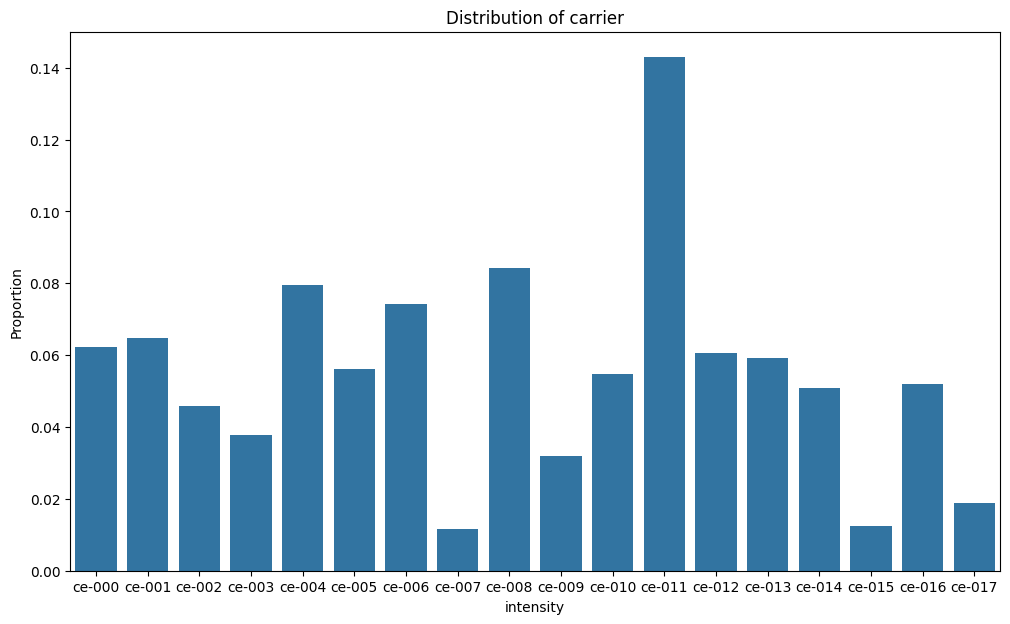

In [34]:
barchart('Distribution of carrier','intensity','Proportion',stat='proportion',x='carrier',data=airplane_df)


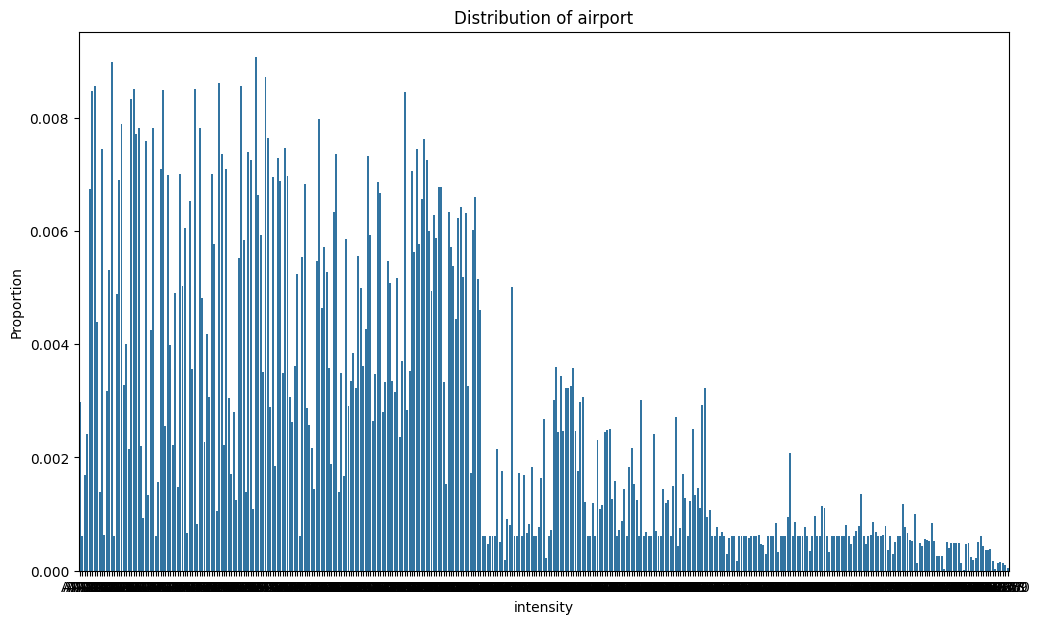

In [35]:
barchart('Distribution of airport','intensity','Proportion',stat='proportion',x='airport',data=airplane_df)


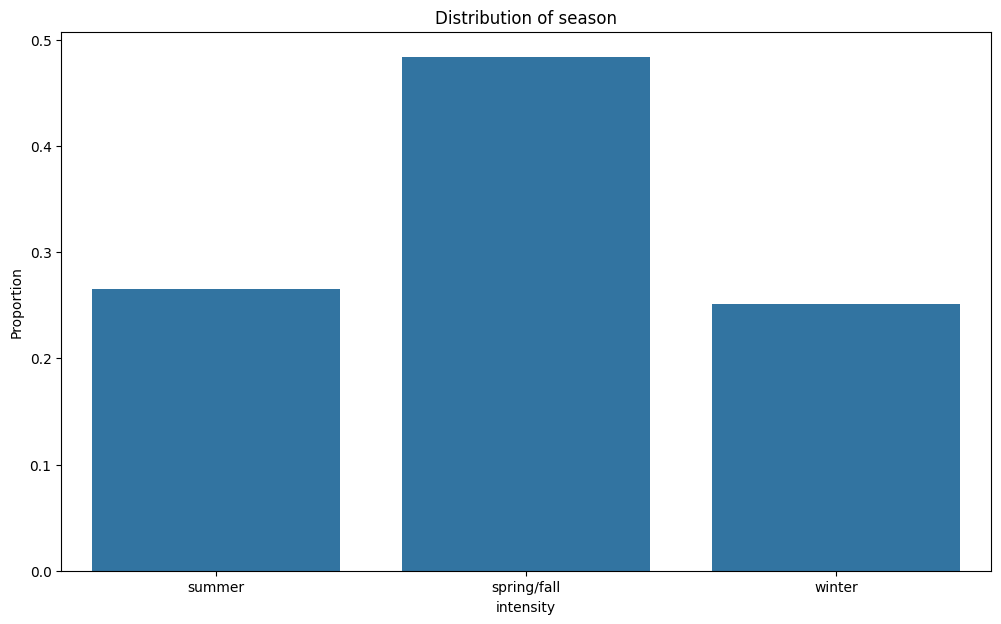

In [36]:
barchart('Distribution of season','intensity','Proportion',stat='proportion',x='season',data=airplane_df)

The distribution by season shows almost equal data but spring/fall appears the highest since it is 2 season combined.

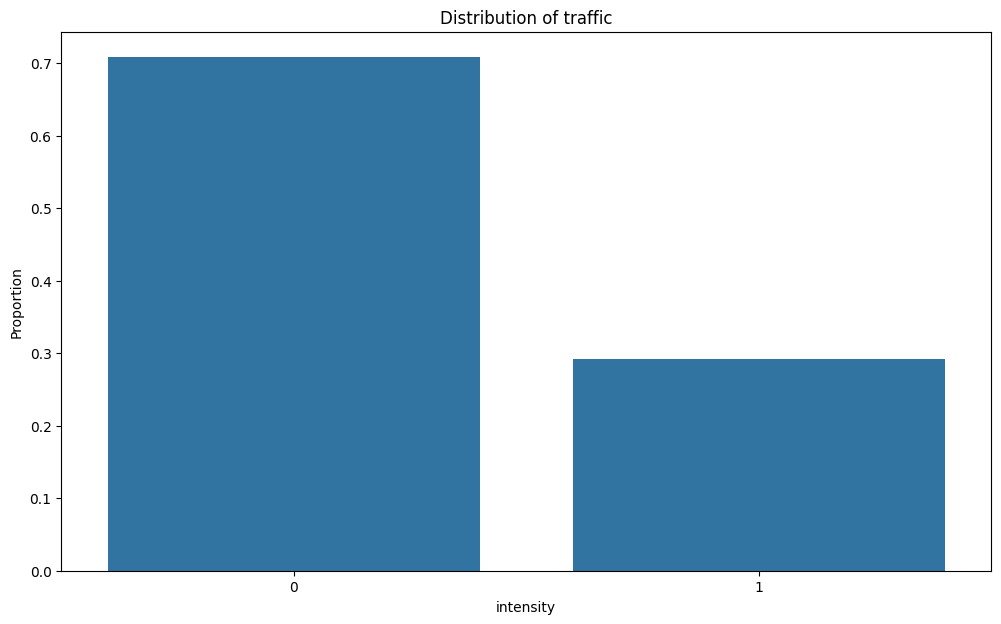

In [37]:
barchart('Distribution of traffic','intensity','Proportion',stat='proportion',x='is_high_traffic',data=airplane_df)

Majority of the records are for low traffic airports.

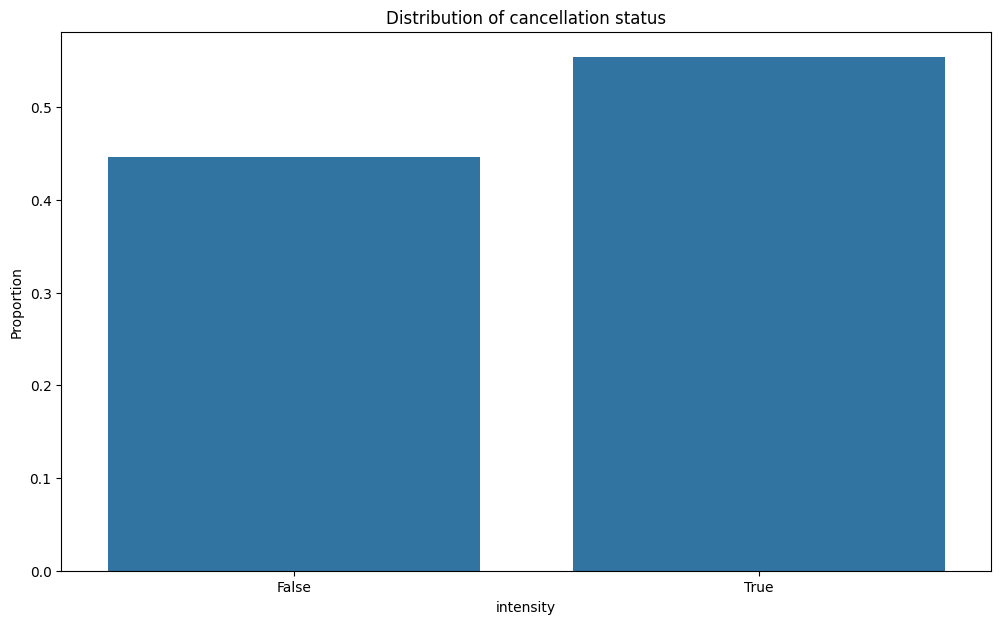

In [38]:
barchart('Distribution of cancellation status','intensity','Proportion',stat='proportion',x='cancellation_flag',data=airplane_df)

The distribution for cancelled flights is slightly higher than the no. of non cancelled flights.

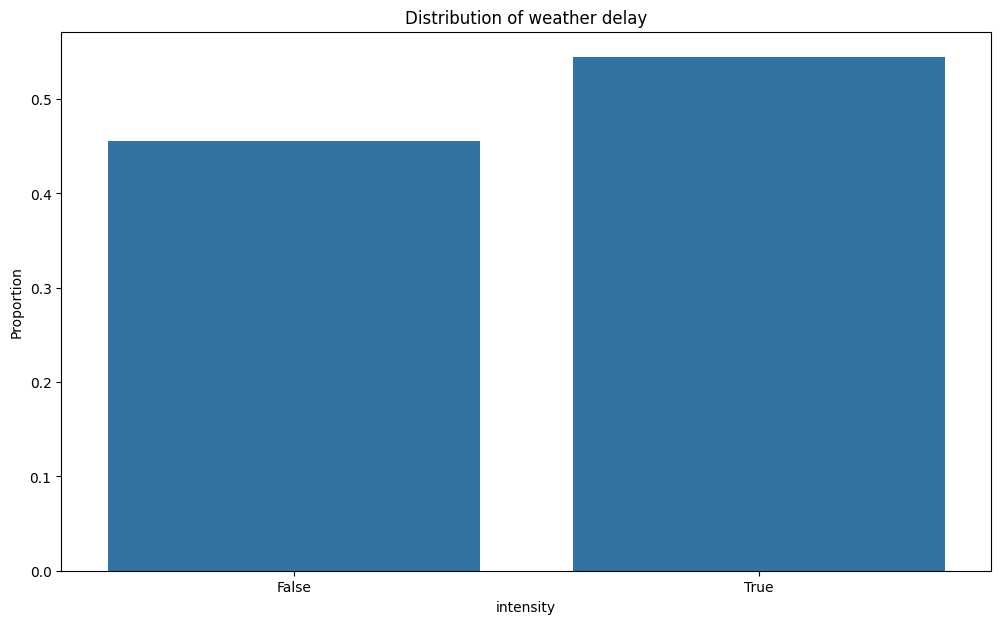

In [39]:
barchart('Distribution of weather delay','intensity','Proportion',stat='proportion',x='weather_delay_flag',data=airplane_df)

A higher number of flights have been cancelled due to weather delays.

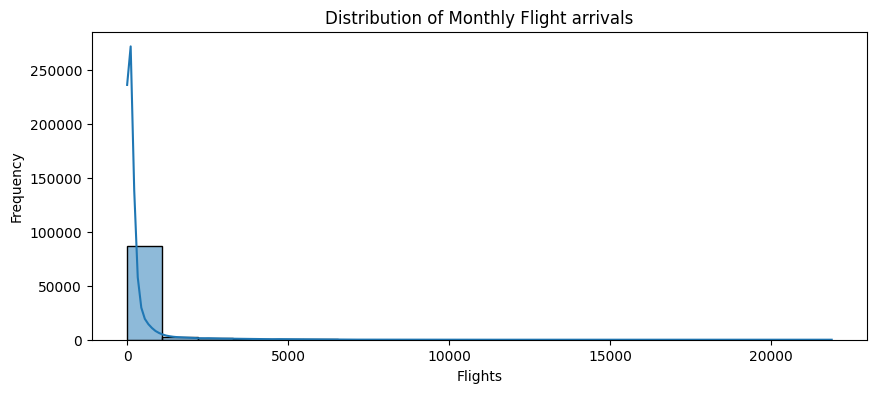

In [40]:
histogram(airplane_df['arr_flights'],'Distribution of Monthly Flight arrivals','Flights','Frequency')


The distribution of monthly flight arrivals (arr_flights) is highly right-skewed, indicating that a large majority of airports handle a relatively low number of flights. The right skew maybe due to a few number of airports handling a larger traffic.

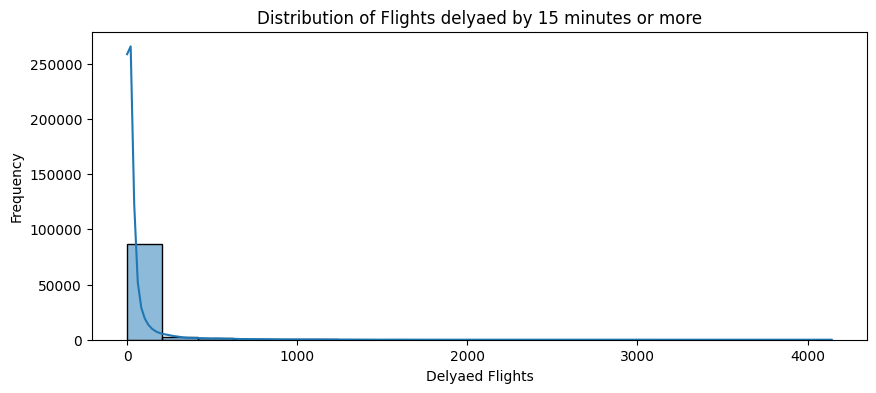

In [41]:
histogram(airplane_df['arr_del15'],'Distribution of Flights delyaed by 15 minutes or more','Delyaed Flights','Frequency')


The distribution for delayed flights is heavily right skewed similar to the arr_flights distribution, this indicates that most entries show a relatively low number of flights delayed by 15 minutes or more, with a long tail extending to much higher values. This suggests for some cases associated with high traffic airports, the delayed flight count can increase .

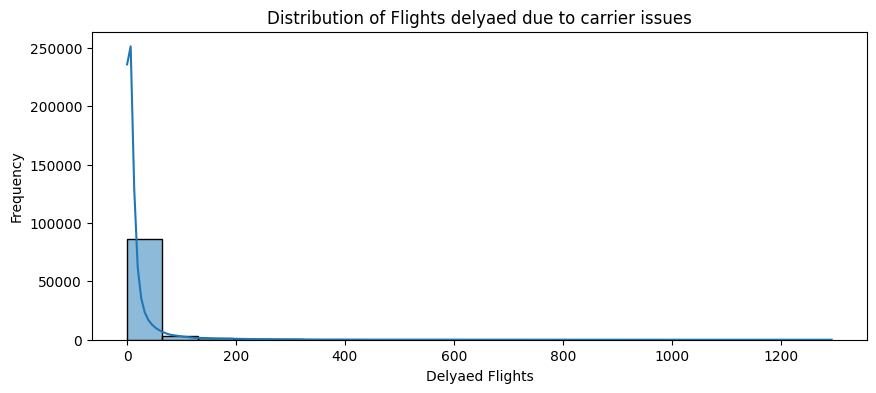

In [42]:
histogram(airplane_df['carrier_ct'],'Distribution of Flights delyaed due to carrier issues','Delyaed Flights','Frequency')


The distribution is heavily right skewed, suggesting low frequency of higher no. of delays due to carrier issue maybe due to change in no. of incoming flights for some months.

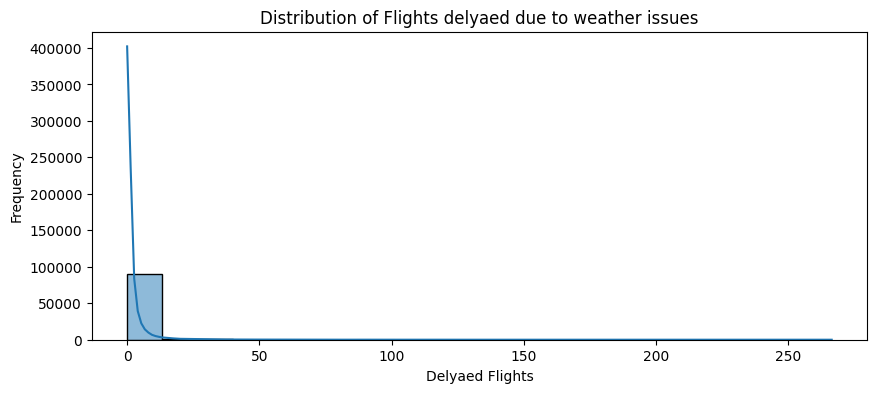

In [43]:
histogram(airplane_df['weather_ct'],'Distribution of Flights delyaed due to weather issues','Delyaed Flights','Frequency')


The distribution is heavily right skewed, suggesting low frequency of higher no. of delays due to weather issue maybe due to adverse weather conditions during a particular period only.

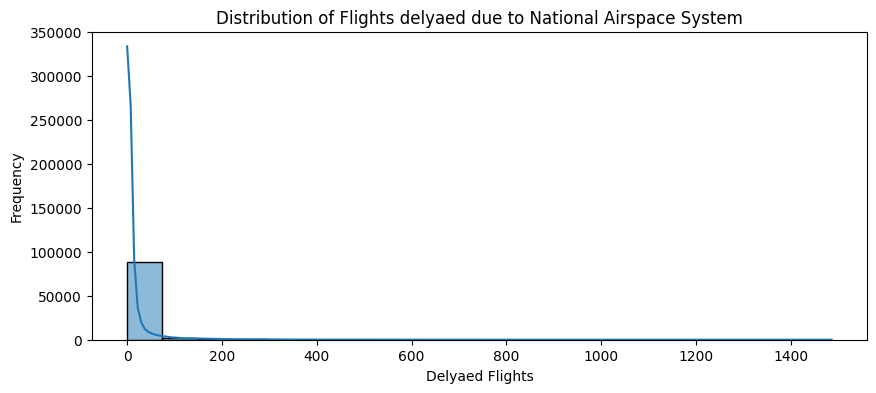

In [44]:
histogram(airplane_df['nas_ct'],'Distribution of Flights delyaed due to National Airspace System','Delyaed Flights','Frequency')


The distribution is heavily right skewed, suggesting delats due to national airspace related issues occur less but outliers exist due to adverse conditions that might occur due to sudden changes in political conditions.

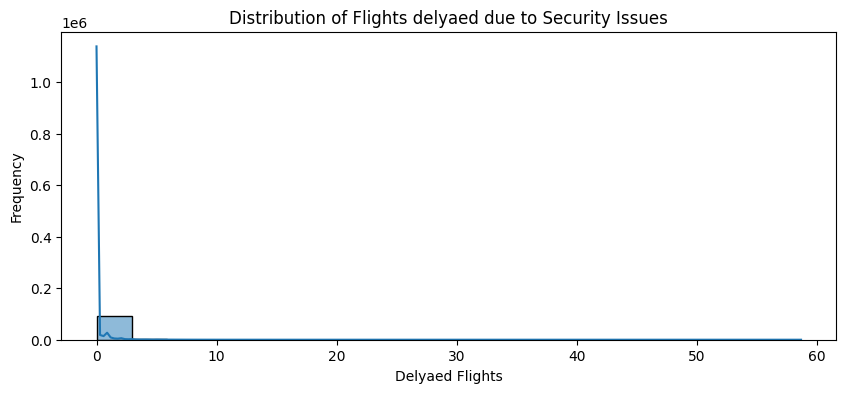

In [45]:
# airplane_df['security_ct'].describe()
histogram(airplane_df['security_ct'],'Distribution of Flights delyaed due to Security Issues','Delyaed Flights','Frequency')


The distribution is highly right skewed suggesting that delays due to security issues is less common.

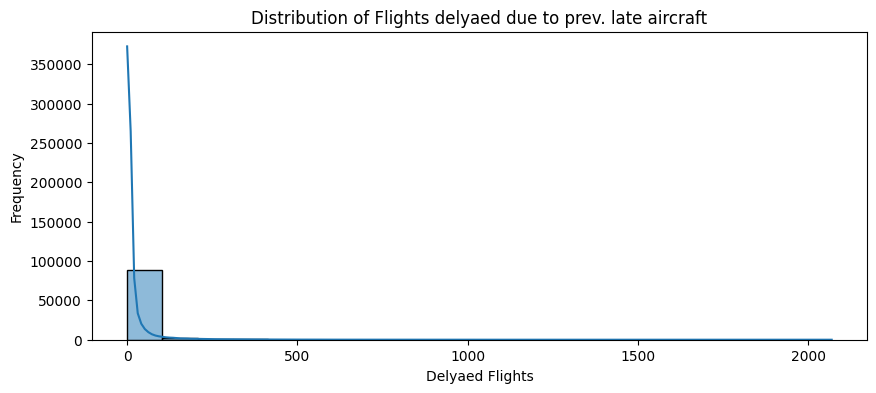

In [46]:
histogram(airplane_df['late_aircraft_ct'],'Distribution of Flights delyaed due to prev. late aircraft','Delyaed Flights','Frequency')


The distribution is heavily right skewed, suggesting low frequency of higher no. of delays due to prev. late aircraft maybe due to heavier traffic periods during certain parts.

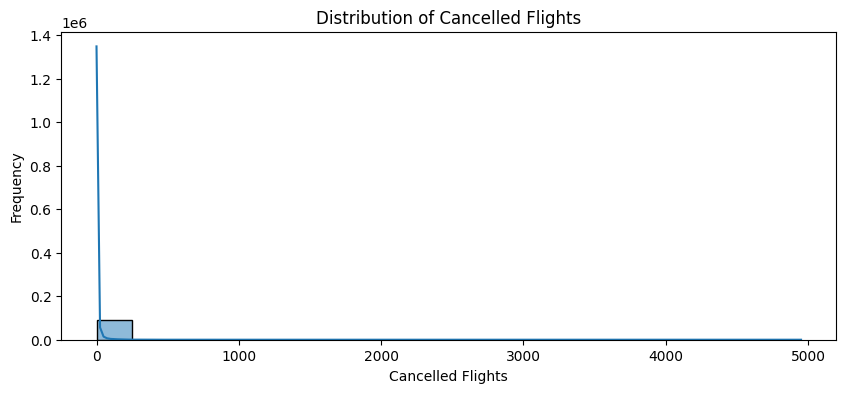

In [47]:
histogram(airplane_df['arr_cancelled'],'Distribution of Cancelled Flights','Cancelled Flights','Frequency')


The distribution is heavily right skewed, suggesting low frequency of higher no. of cancellations maybe due to weather issues, monthly seasonal traffic changes.

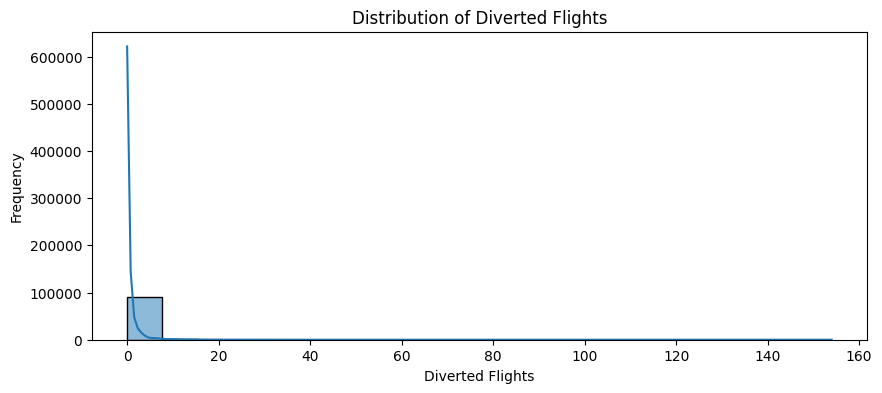

In [48]:
histogram(airplane_df['arr_diverted'],'Distribution of Diverted Flights','Diverted Flights','Frequency')

The distribution is heavily right skewed with an overall low no. of diverted flights suggesting flight diversions only occur during a special occassion.

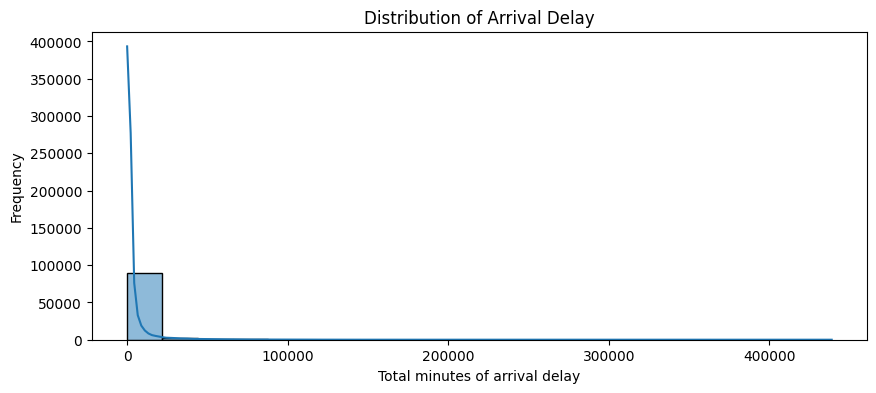

In [49]:
histogram(airplane_df['arr_delay'],'Distribution of Arrival Delay','Total minutes of arrival delay','Frequency')

The arrival delay has very high durations which makes it right skewed suggesting only a small number of flights experience longer delays which might be affected by higher volume of traffic during certain months or due to occassional operational delays.

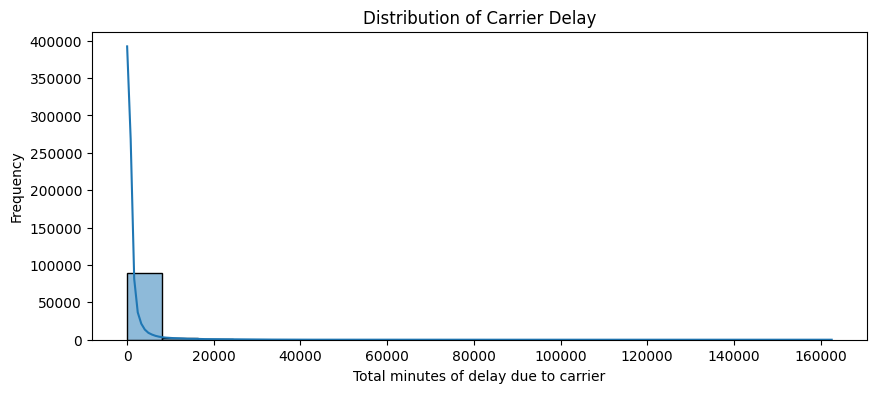

In [50]:
histogram(airplane_df['carrier_delay'],'Distribution of Carrier Delay','Total minutes of delay due to carrier','Frequency')

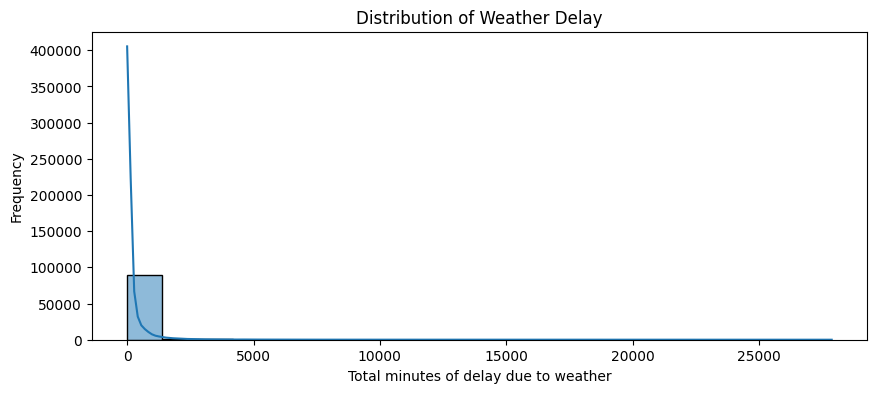

In [51]:
histogram(airplane_df['weather_delay'],'Distribution of Weather Delay','Total minutes of delay due to weather','Frequency')

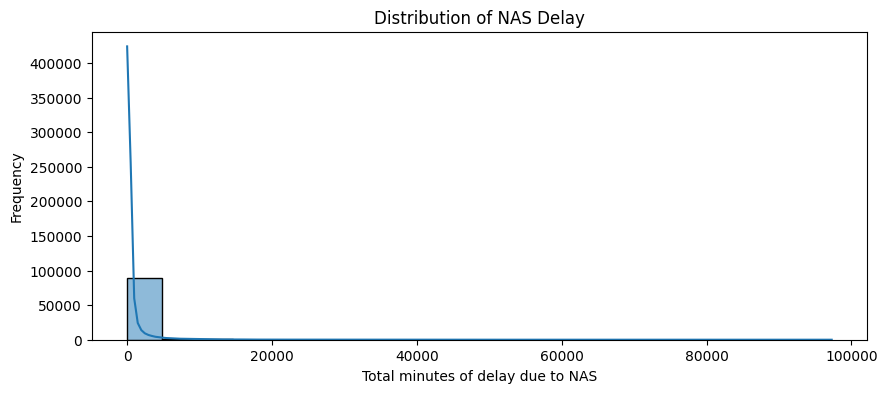

In [52]:
histogram(airplane_df['nas_delay'],'Distribution of NAS Delay','Total minutes of delay due to NAS','Frequency')

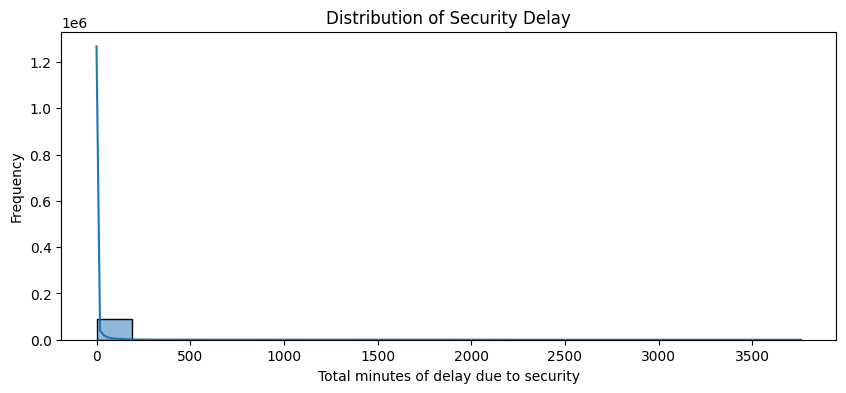

In [53]:
histogram(airplane_df['security_delay'],'Distribution of Security Delay','Total minutes of delay due to security','Frequency')

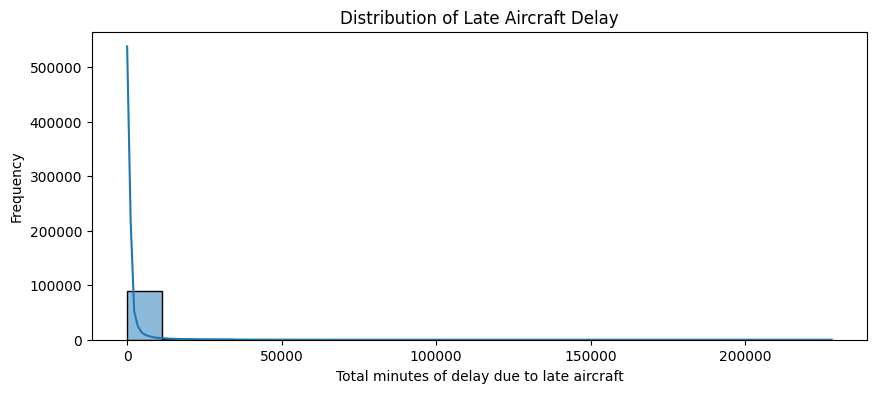

In [54]:
histogram(airplane_df['late_aircraft_delay'],'Distribution of Late Aircraft Delay','Total minutes of delay due to late aircraft','Frequency')

## Bivariate Analysis

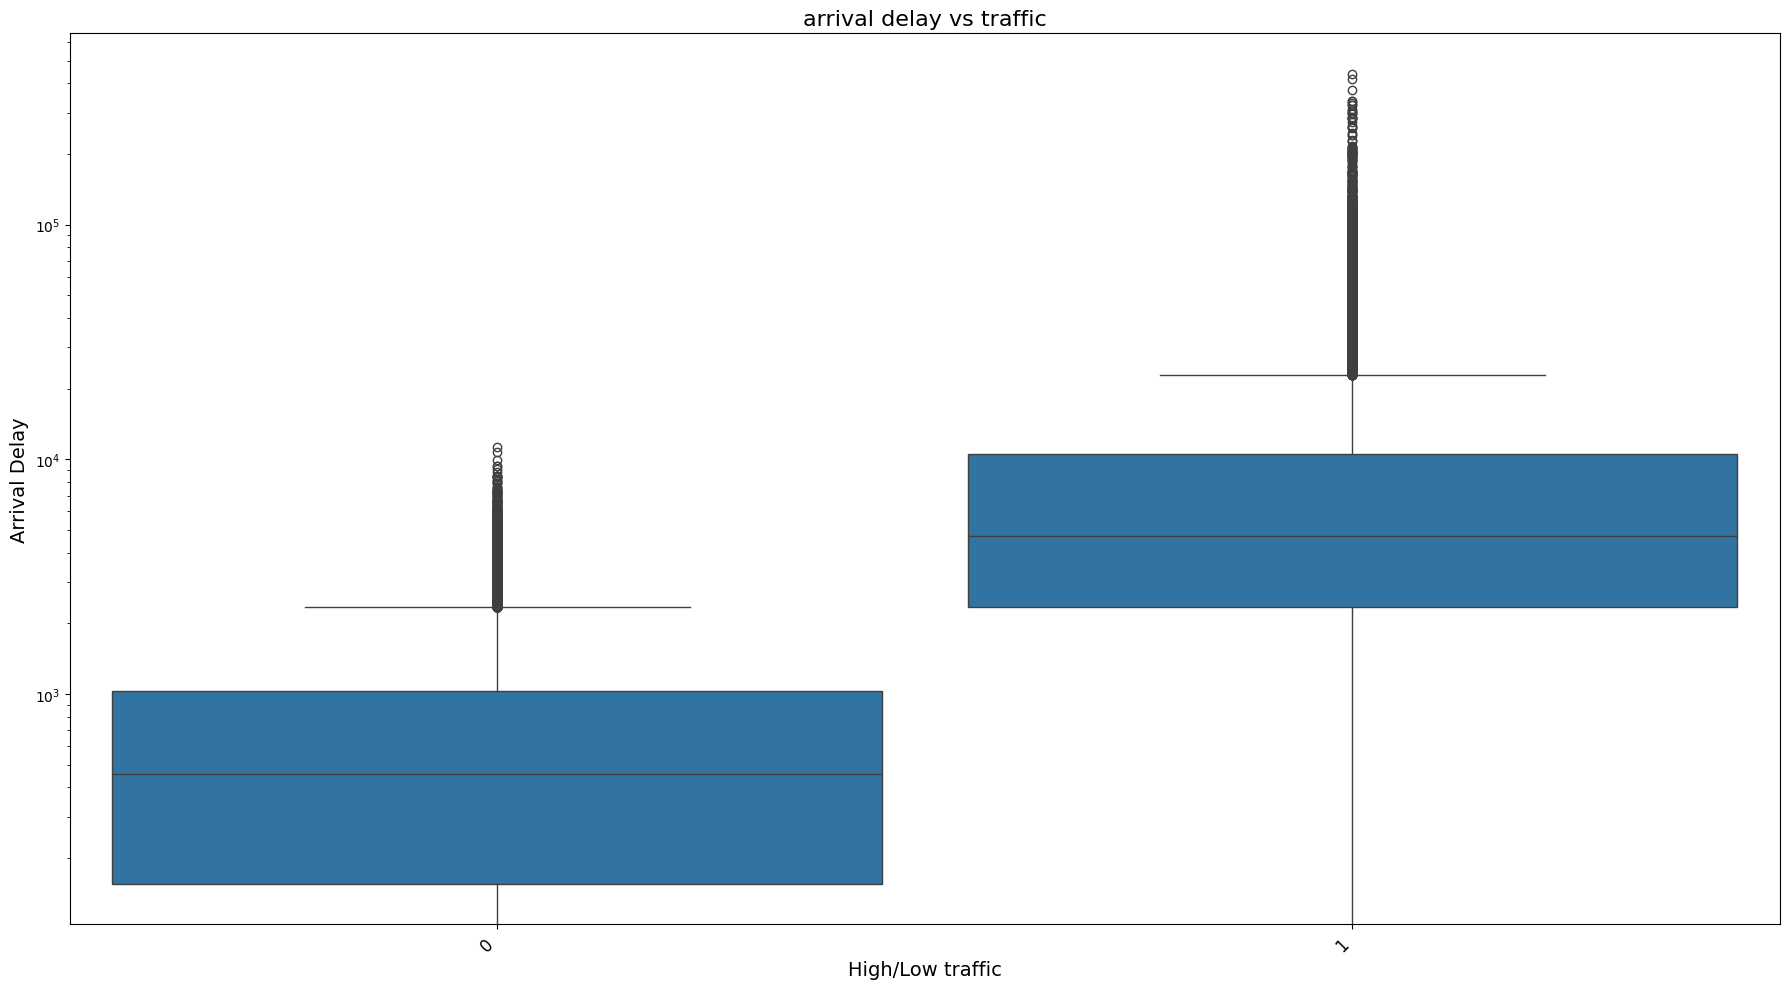

In [55]:
boxplot('is_high_traffic','arr_delay',airplane_df,'arrival delay vs traffic','High/Low traffic','Arrival Delay')


*   The median delay for high traffic airports is greater than that for low traffic suggesting flights arriving at high traffic airports experience longer delays.
*  High traffic airports show more extreme outliers, suggesting longer delays occuring at high traffic airports.

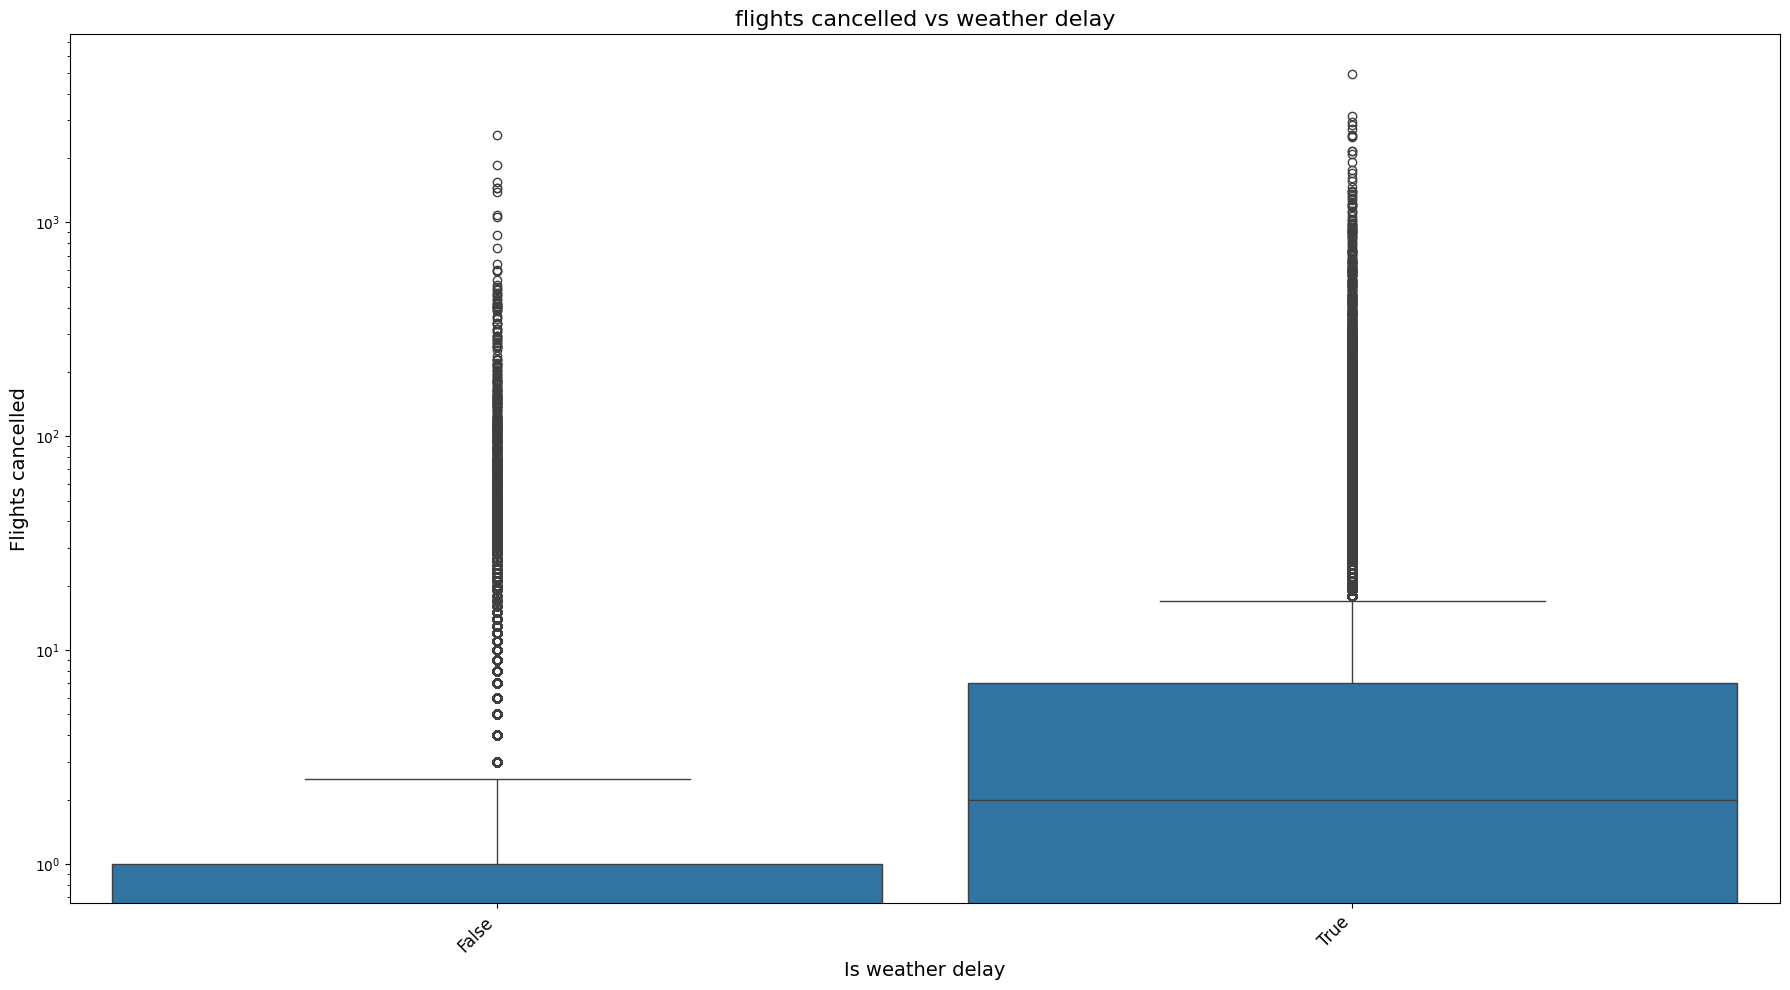

In [56]:
boxplot('weather_delay_flag','arr_cancelled',airplane_df,'flights cancelled vs weather delay','Is weather delay','Flights cancelled')

The plot shows a higher number of cancellations associated with weather delay, suggesting more flights tend to get cancelled during extreme weather conditions.

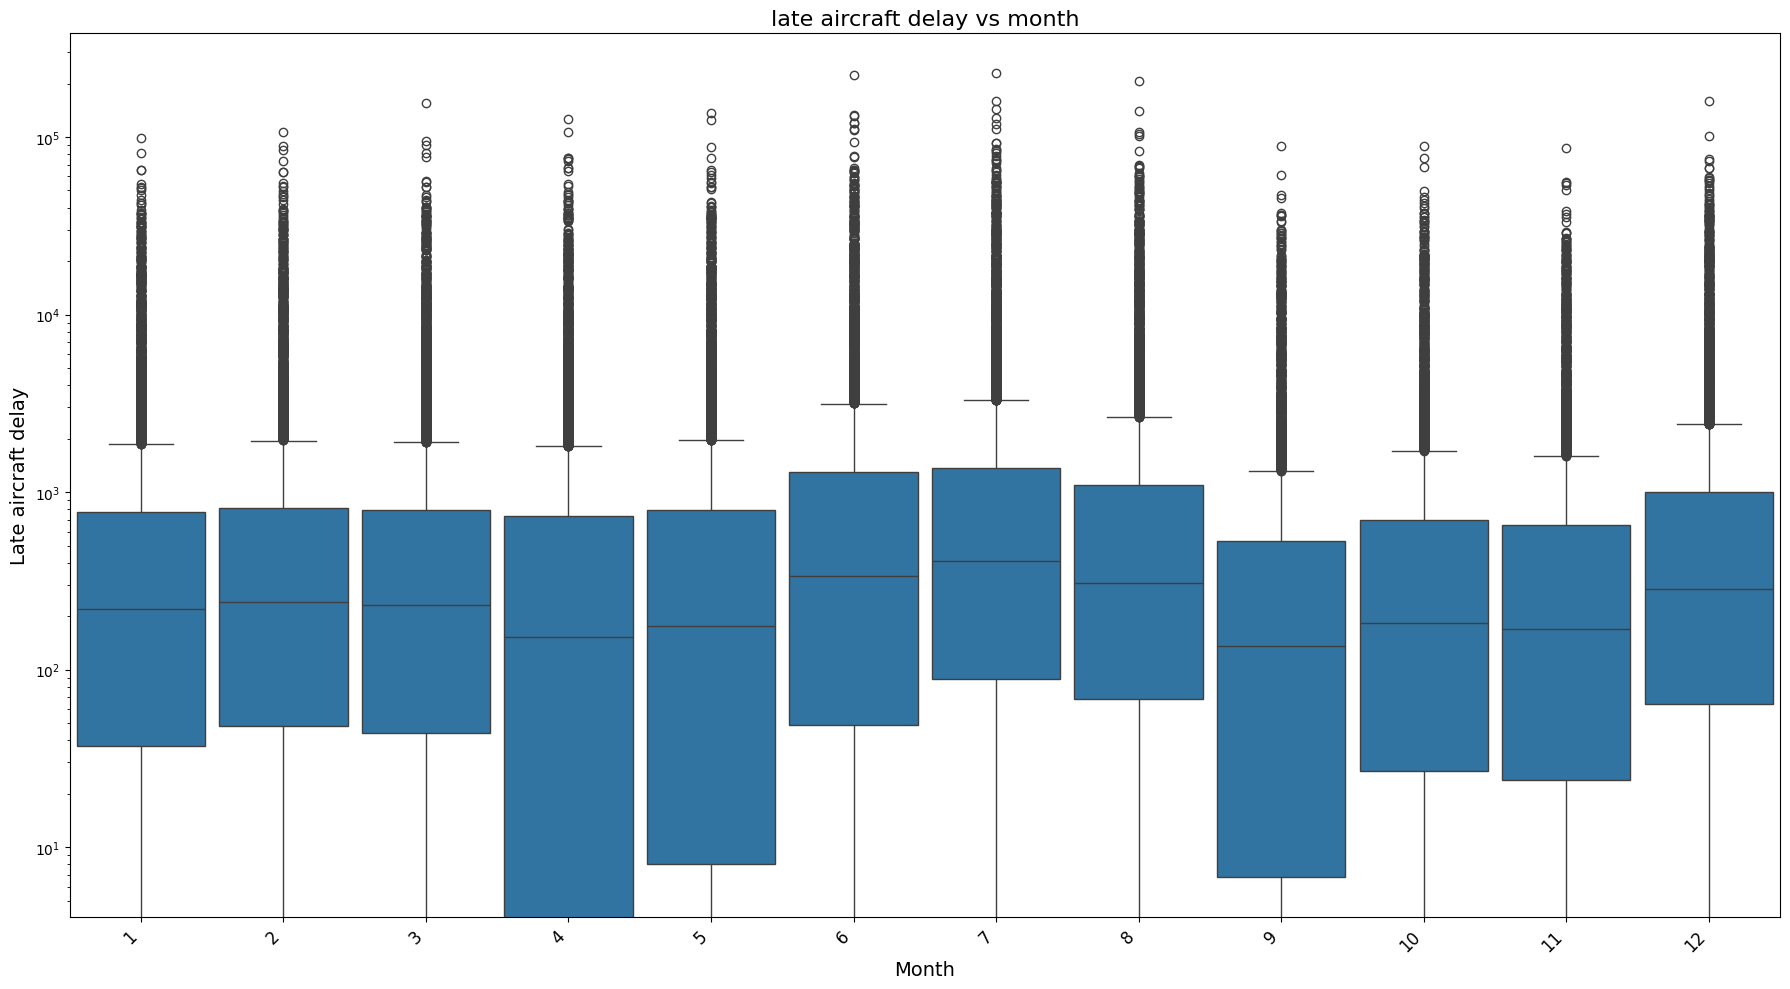

In [57]:
boxplot('month','late_aircraft_delay',airplane_df,'late aircraft delay vs month','Month','Late aircraft delay')

The highest delays are experienced during the months of June, July , August while the second highest is during December and January suggesting more people might be traveling during these months.

In [58]:
# Get unique airport codes
unique_airports = airplane_df['airport'].unique()

# Randomly select four sample airports
sample_airports = np.random.choice(unique_airports, 4, replace=False).tolist()

# Filter the DataFrame for these sample airports
sample_airplane_df = airplane_df[airplane_df['airport'].isin(sample_airports)].copy()

print(f"Filtered DataFrame for airports: {sample_airports}")
display(sample_airplane_df.head())

Filtered DataFrame for airports: ['AT-87', 'AT-252', 'AT-364', 'AT-18']


,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,season,is_high_traffic,weather_delay_flag,cancellation_flag
18,2023,8,ce-000,AT-18,92.0,20.0,3.74,0.00,9.41,0.0,...,1375.0,398.0,0.0,448.0,0.0,529.0,summer,0,False,True
87,2023,8,ce-000,AT-87,98.0,12.0,4.40,0.02,2.70,0.0,...,866.0,238.0,4.0,97.0,0.0,527.0,summer,0,True,True
112,2023,8,ce-001,AT-18,62.0,10.0,3.76,0.00,1.41,0.0,...,406.0,160.0,0.0,74.0,0.0,172.0,summer,0,False,False
395,2023,8,ce-004,AT-18,133.0,17.0,5.57,2.66,2.42,0.0,...,880.0,278.0,177.0,94.0,0.0,331.0,summer,0,True,True
707,2023,8,ce-006,AT-87,13.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,summer,0,False,False


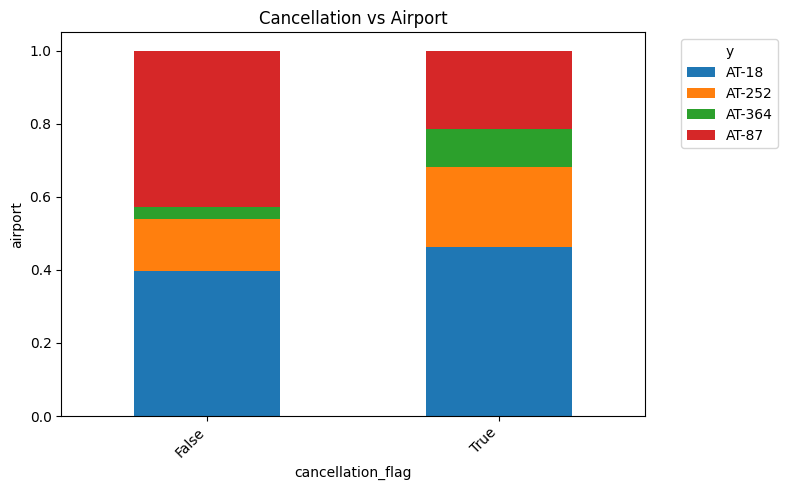

In [59]:
stacked_barchart(sample_airplane_df['cancellation_flag'],sample_airplane_df['airport'],'cancellation_flag','airport','Cancellation vs Airport')


The bar chart shoes that cancellations vary across airports. Certain airports may experience low number of cancellations due to less traffic.

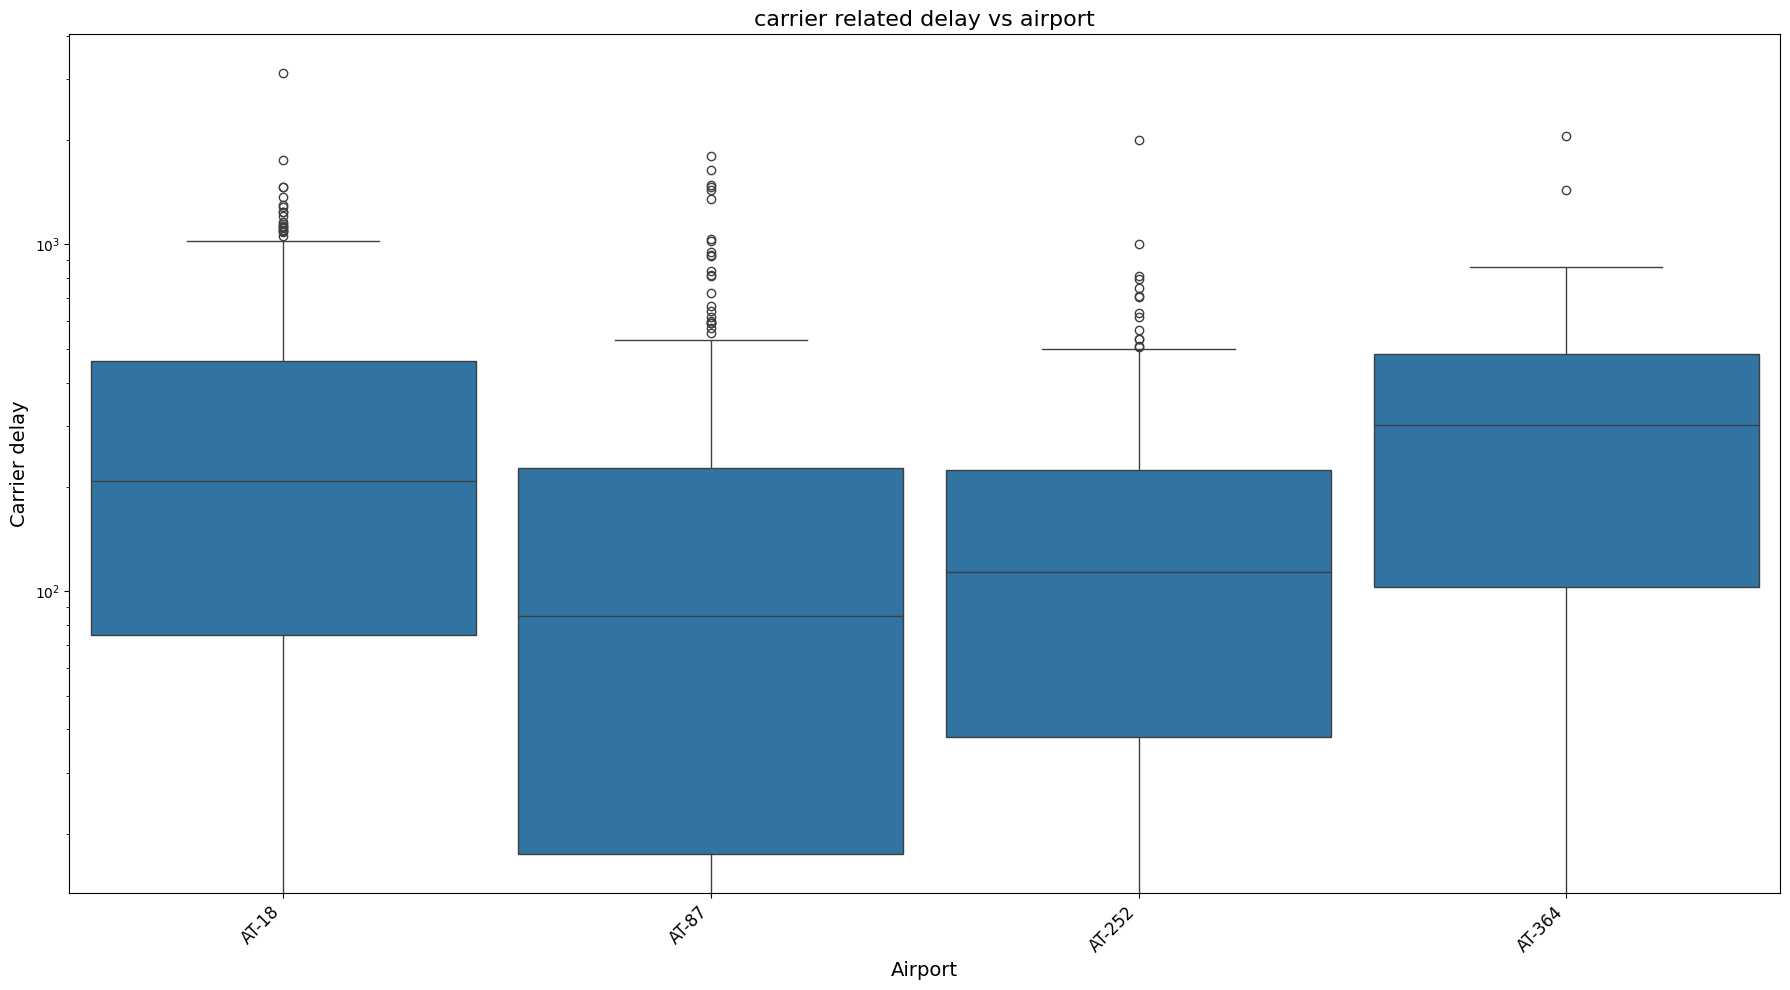

In [60]:
boxplot('airport','carrier_delay',sample_airplane_df,'carrier related delay vs airport','Airport','Carrier delay')

Carrier related delays vary across airports, suggesting that certain airports may experience staff shortages or operational issues causing more delays.

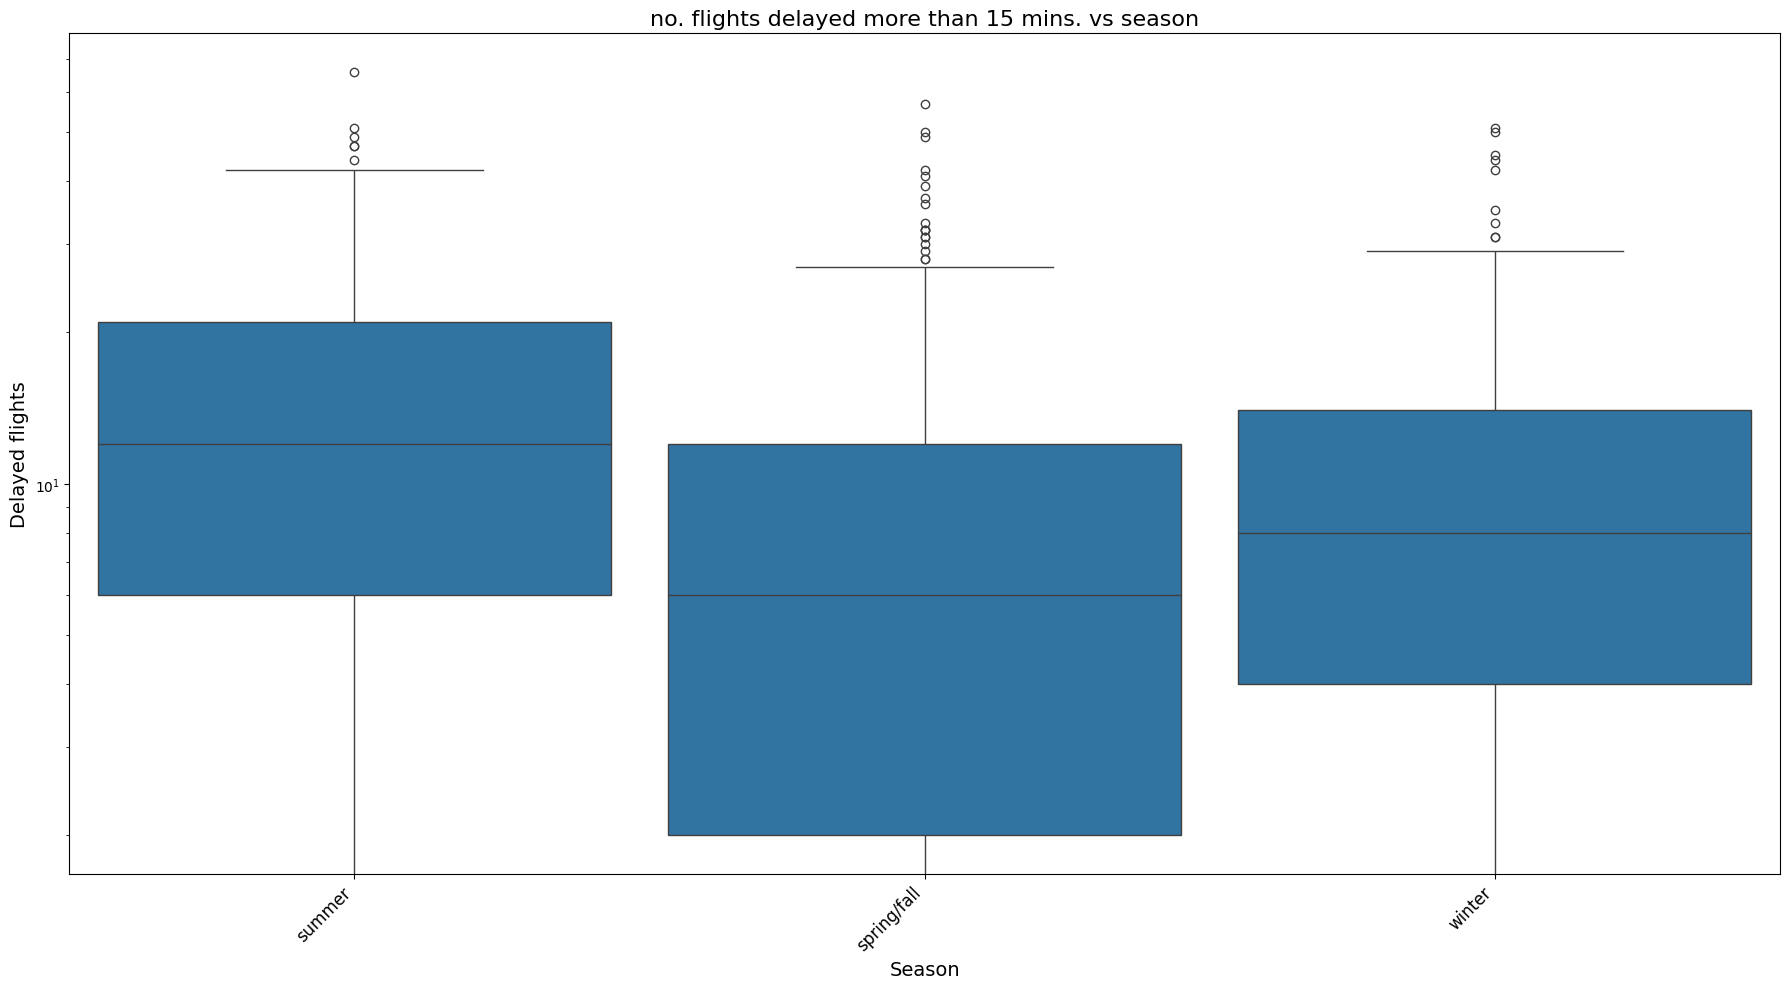

In [61]:
boxplot('season','arr_del15',sample_airplane_df,'no. flights delayed more than 15 mins. vs season','Season','Delayed flights')

The average number of delyaed flights for summer and winter shows a higher number icating that more people might be traveling during that season and hence busy airports. The outliers for spring/fall have  higher values since the total combined flights for these 2 seasons is more.

## Multivariate Analysis

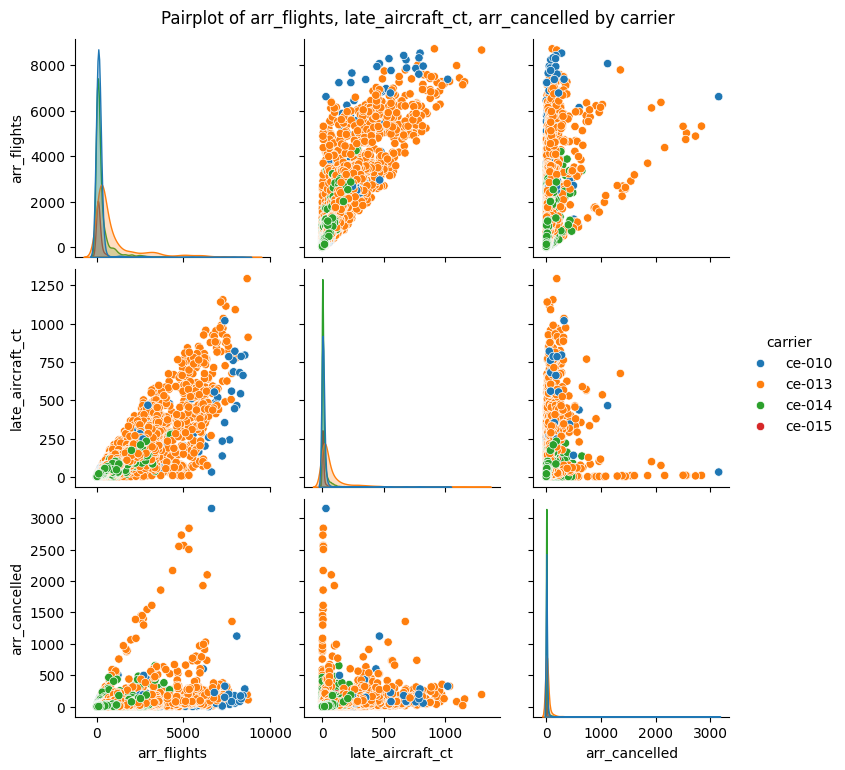

In [62]:
vars_to_plot = ['arr_flights', 'late_aircraft_ct', 'arr_cancelled']
# Get unique career codes
unique_career = airplane_df['carrier'].unique()

# Randomly select four sample careers
sample_career = np.random.choice(unique_career, 4, replace=False).tolist()
# Filter the DataFrame for these sample careers
sample_career_df = airplane_df[airplane_df['carrier'].isin(sample_career)].copy()
hue_col = 'carrier'

pairplot_with_hue(
    data=sample_career_df,
    vars_to_plot=vars_to_plot,
    hue_col=hue_col,
    title=f'Pairplot of {', '.join(vars_to_plot)} by {hue_col}'
)

* There appears to be a positive
correlation between the number of arriving flights and the count of late aircraft delays. This suggests that carriers operating at a higher volume tend to experience more delyas.
* Although a direct relationship between the number of flights and the number of cancellations can not be attributed, there seems to be a positive correlation for a certian carrer, suggesting dependency on carrier related operational logistics for cancellations. Higher flight volumes tend to be associated with more cancellations.
 * While not a direct causation, it suggests that a higher count of late aircraft delays might correspond to a higher number of cancellations. This could be due to cascading effects where late aircraft disrupt schedules, leading to subsequent cancellations, especially under operational stress.

### Correlation Analysis

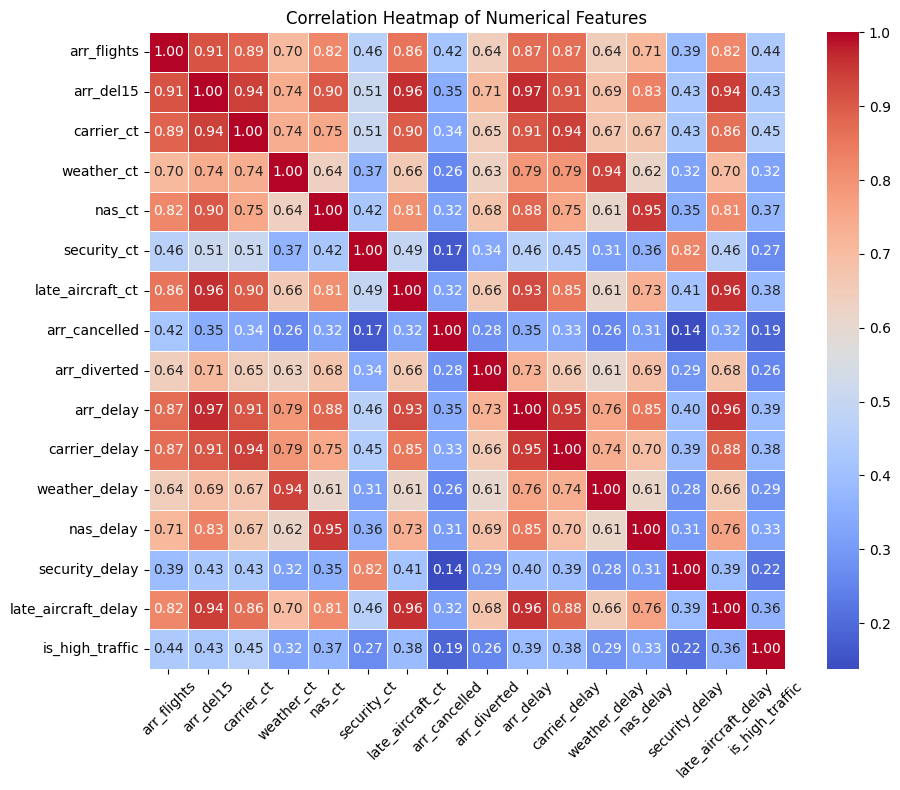

In [63]:
numeric_df = airplane_df.select_dtypes(include=np.number)
heatmap_numerical(numeric_df)


* There is a high positive corelation between flight volume and arrival delays suggesting high traffic airport experience more delyas.
* It appears that carrier related delays have a strong positive corelation with overall delay, suggesting it to be a strong contributing factor.
* Delays attributed to national airspace system and weather related delays are the next most correalted factors contributing to overall delay.

# **Decision**

In this phase, we use hypothesis testing to validate the insights uncovered during EDA and answer key business questions with statistical confidence.

By applying tests like t-tests, chi-square tests, and ANOVA tests, we assess whether observed differences or relationships in the data are statistically significant or due to chance. Each test begins with a null hypothesis ($H_0$) and helps us determine if there's enough evidence to support the alternative hypothesis ($H_a$).

This step ensures our conclusions are data-driven and evidence-based, forming a solid foundation for strategic decision-making.

# **Hypothesis Testing**

## 1. Does the average arrival delay differ between high-traffic airports and low-traffic airports?

* H0: The average arrival delay is the same for high traffic airports and low traffice airports.
* Ha: The average arrival delay differs for high traffic airports and low traffice airports.
* H0:μ1=μ2

* Ha:μ1≠μ2

 Two-tailed test can be used since it checks for  significance of the difference between two independent means. Since the population standard deviations are unknown and the samples are independent, an independent samples t-test (also known as a two-sample t-test) is appropriate.

Let the significance level (α) be 0.05.

In [64]:
avg_delay_high_traffic = airplane_df[airplane_df['is_high_traffic'] == 1]['arr_delay']
avg_delay_low_traffic = airplane_df[airplane_df['is_high_traffic'] == 0]['arr_delay']

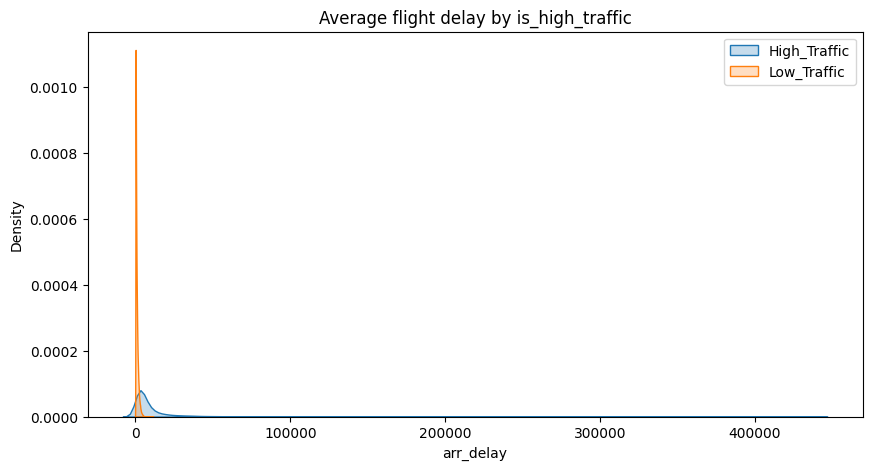

In [65]:
plt.figure(figsize=(10,5))
sns.kdeplot(avg_delay_high_traffic, label='High_Traffic', fill='fill')
sns.kdeplot(avg_delay_low_traffic, label='Low_Traffic', fill='fill')
plt.title('Average flight delay by is_high_traffic')
plt.legend()
plt.show()

Although the distributions appear to be right skewed, since the sample size > 30 the assumption of normally distributed data will be satisfied according to central limit theorem.

In [66]:
from scipy.stats import levene

stat, p = levene(avg_delay_high_traffic,avg_delay_low_traffic)
print(f"Levene’s Test - Statistic: {stat:.2f}, P-value: {p:.4f}")

Levene’s Test - Statistic: 11128.82, P-value: 0.0000


Since **the** assumption of equal variances is not met (checked using Levene’s test), we set equal_var=False to perform Welch’s t-test, which adjusts for unequal variances.

In [67]:
t_stat, p_value = ttest_ind(avg_delay_high_traffic,avg_delay_low_traffic, equal_var=False)
print(f"T-test result - T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")


T-test result - T-statistic: 82.34, P-value: 0.0000


In [68]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.0 is less than the level of significance, we reject the null hypothesis.


The p-value (0.0000) is significantly less than α
 (0.05), providing strong evidence against the null hypothesis.

Since this is a two-tailed test, we conclude that the average arrival delay differs significantly between low traffice and high traffic airports.

## 2. Is the average number of flights cancelled associated with weather-related delays across airports?

* H0: The average number of flights cancelled  is the same for airports with weather related delyas and airports that do not experience weather realted delays.
* Ha: The average arrival delay differs for airports with and without weather related delays.
* H0:μ1=μ2

* Ha:μ1≠μ2

Two-tailed test can be used since it checks for  significance of the difference between two independent means. Since the population standard deviations are unknown and the samples are independent, an independent samples t-test (also known as a two-sample t-test) is appropriate.

Let the significance level (α) be 0.05.

In [69]:
cancelled_weather_delay = airplane_df[airplane_df['weather_delay_flag'] == 1]['arr_cancelled']
cancelled_no_weather_delay = airplane_df[airplane_df['weather_delay_flag'] == 0]['arr_cancelled']


In [70]:
stat, p = levene(cancelled_weather_delay,cancelled_no_weather_delay)
print(f"Levene’s Test - Statistic: {stat:.2f}, P-value: {p:.4f}")

Levene’s Test - Statistic: 612.75, P-value: 0.0000


Since **the** assumption of equal variances is not met (checked using Levene’s test), we set equal_var=False to perform Welch’s t-test, which adjusts for unequal variances.

In [71]:
t_stat, p_value = ttest_ind(cancelled_weather_delay,cancelled_no_weather_delay, equal_var=False)
print(f"T-test result - T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")


T-test result - T-statistic: 27.65, P-value: 0.0000


In [72]:
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 1.954812487924553e-167 is less than the level of significance, we reject the null hypothesis.


The p-value (1.954812487924553e-167) is significantly less than α
 (0.05), providing strong evidence against the null hypothesis.

Since this is a two-tailed test, we conclude that the average no. of cancellations differs significantly between airports with weather delays and airports without weather delays.

## 3. Is a flight’s cancellation status (Yes/No) associated with the origin airport for a sample of four airports?

* H0: The flight cancellation status and origin airport are independent of each other.
* Ha: The flight cancellation status and origin airport are dependent of each other.

To test dependency of 2 categorical variables, a chi-square test of independence can be used.

Let the significance level (α) be 0.05.

In [73]:
contingency_table = pd.crosstab(sample_airplane_df['airport'], sample_airplane_df['cancellation_flag'])

In [74]:
chi, p, dof, expected = chi2_contingency(contingency_table)
print("p_value", p)

p_value 9.890345797197777e-10


p_values is significantly less, indicating rejection of null hypothesis.
There is sufficient evidence to conclude that flight cancellation is dependent on the airport.

## 4. Does the average delay caused by late-arriving aircraft differ between months of the year?

* H0: The average delay by late arriving air crafts are the same across months of the year.
* Ha: At least one month  has a mean delay that is different.

This involves more than two population means. Hence\ a one-way ANOVA test for this case.

Let's set the level of significane (α
) as 0.05.

In [75]:
# 1. Prepare data for ANOVA - create a list of late_aircraft_delay for each month
monthly_delays = [airplane_df['late_aircraft_delay'][airplane_df['month'] == month] for month in range(1, 13)]

# 2. Check for homogeneity of variances using Levene's test
# H0: Variances are equal across groups
# Ha: At least one group variance is different
stat, p_levene = levene(*monthly_delays)
print(f"Levene's Test - Statistic: {stat:.2f}, P-value: {p_levene:.4f}")



Levene's Test - Statistic: 44.80, P-value: 0.0000


* Since the p-value is less than the 5% significance level, we reject the null hypothesis of homogeneity of variances.

* However, since ANOVA is fairly robust to mild violations of equal variance, we can go ahead with ANOVA.

In [76]:
from scipy.stats import shapiro
for i, delays in enumerate(monthly_delays):
        stat, p_shapiro = shapiro(delays)
        print(f"  Month {i+1} (n={len(delays)}): Statistic={stat:.4f}, P-value={p_shapiro:.4f}")
        if p_shapiro < 0.05:
            print("    -> Reject H0 (not normal)")
        else:
            print("    -> Fail to reject H0 (normal)")



  Month 1 (n=8337): Statistic=0.2928, P-value=0.0000
    -> Reject H0 (not normal)
  Month 2 (n=8181): Statistic=0.2822, P-value=0.0000
    -> Reject H0 (not normal)
  Month 3 (n=8368): Statistic=0.2692, P-value=0.0000
    -> Reject H0 (not normal)
  Month 4 (n=8200): Statistic=0.2669, P-value=0.0000
    -> Reject H0 (not normal)
  Month 5 (n=8102): Statistic=0.2646, P-value=0.0000
    -> Reject H0 (not normal)
  Month 6 (n=8128): Statistic=0.2693, P-value=0.0000
    -> Reject H0 (not normal)
  Month 7 (n=8174): Statistic=0.2740, P-value=0.0000
    -> Reject H0 (not normal)
  Month 8 (n=8232): Statistic=0.2694, P-value=0.0000
    -> Reject H0 (not normal)
  Month 9 (n=6718): Statistic=0.2725, P-value=0.0000
    -> Reject H0 (not normal)
  Month 10 (n=6662): Statistic=0.2874, P-value=0.0000
    -> Reject H0 (not normal)
  Month 11 (n=6660): Statistic=0.2936, P-value=0.0000
    -> Reject H0 (not normal)
  Month 12 (n=6715): Statistic=0.2893, P-value=0.0000
    -> Reject H0 (not normal)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8337.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8181.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8368.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8200.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stat

This provides strong statistical evidence that the late aircraft delay values in each group do not follow a normal distribution.

However, this assumption can be considered approximately satisfied when the sample size is large (typically n>30
 per group), as per the Central Limit Theorem.

In [77]:
# 3. Perform One-Way ANOVA
# H0: The average delay by late arriving aircraft is the same across months of the year.
# Ha: At least one month has a mean delay that is different.
alpha = 0.05
f_stat, p_anova = f_oneway(*monthly_delays)

print(f"\nOne-Way ANOVA - F-statistic: {f_stat:.2f}, P-value: {p_anova:.4f}")

# 4. Interpret the results
if p_anova < alpha:
    print(f'\nAs the ANOVA p-value ({p_anova:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.')
    print('Conclusion: There is sufficient evidence to conclude that the average delay caused by late-arriving aircraft differs significantly between months of the year.')
else:
    print(f'\nAs the ANOVA p-value ({p_anova:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.')
    print('Conclusion: There is no sufficient evidence to conclude that the average delay caused by late-arriving aircraft differs significantly between months of the year.')


One-Way ANOVA - F-statistic: 49.87, P-value: 0.0000

As the ANOVA p-value (0.0000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is sufficient evidence to conclude that the average delay caused by late-arriving aircraft differs significantly between months of the year.


## 5. Does the average carrier-related delay minutes differ across origin airports?

* H0: The average carrier related delay  is the same across origin airports.
* Ha: At least one airport  has a mean delay that is different.


This involves more than two population means. Hence\ a one-way ANOVA test for this case.
* Let's set the level of significane (α
) as 0.05.


In [78]:
print(sample_airplane_df['airport'].unique())
airport_1 = sample_airplane_df[sample_airplane_df['airport'] == 'AT-65']['carrier_delay']
airport_2 = sample_airplane_df[sample_airplane_df['airport'] == 'AT-116']['carrier_delay']
airport_3 = sample_airplane_df[sample_airplane_df['airport'] == 'AT-148']['carrier_delay']
airport_4 = sample_airplane_df[sample_airplane_df['airport'] == 'AT-336']['carrier_delay']

w, p_value = shapiro(airport_1)
print('The p-value is', p_value)
w, p_value = shapiro(airport_2)
print('The p-value is', p_value)
w, p_value = shapiro(airport_3)
print('The p-value is', p_value)
w, p_value = shapiro(airport_4)
print('The p-value is', p_value)


['AT-18' 'AT-87' 'AT-252' 'AT-364']
The p-value is nan
The p-value is nan
The p-value is nan
The p-value is nan


/tmp/ipykernel_11699/639981852.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  w, p_value = shapiro(airport_1)
/tmp/ipykernel_11699/639981852.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  w, p_value = shapiro(airport_2)
/tmp/ipykernel_11699/639981852.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  w, p_value = shapiro(airport_3)
/tmp/ipykernel_11699/639981852.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  w, p_value = shapiro(airport_4)


* Since p values is less than 0.05, the null hypothesis is rejected. Therefore data is not normally distributed.
* However, this assumption can be considered approximately satisfied when the sample size is large (typically n>30
 per group), as per the Central Limit Theorem.

In [79]:
statistic, p_value = levene(airport_1,
                            airport_2,
                            airport_3,
                            airport_4)
print('The p-value is', p_value)

The p-value is nan


/tmp/ipykernel_11699/3517430900.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  statistic, p_value = levene(airport_1,


* Since the p-value is less than the 5% significance level, we reject the null hypothesis of homogeneity of variances.

* However, since ANOVA is fairly robust to mild violations of equal variance, we can go ahead with ANOVA.

In [80]:
# find the p-value
test_stat, p_value = f_oneway(airport_1,airport_2,airport_3,airport_4)
print('The p-value is ', p_value)

The p-value is  nan


/tmp/ipykernel_11699/3010125878.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  test_stat, p_value = f_oneway(airport_1,airport_2,airport_3,airport_4)


In [81]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value nan is greater than the level of significance, we fail to reject the null hypothesis.


Therefore, we conclude that there is a statistically significant difference in mean carrier delay among different airports.

## 6. Does the average number of flights delayed more than 15 minutes differ across seasons?

* H0: The average number of flights delayed more than 15 minutes  is the same across seasons.
* Ha: At least one season has a mean no. of flights that is different.

This involves more than two population means. Hence\ a one-way ANOVA test for this case.
* Let's set the level of significane (α
) as 0.05.

In [ ]:
summer = airplane_df[airplane_df['season'] == 'summer']['arr_del15']
springfall = airplane_df[airplane_df['season'] == 'spring/fall']['arr_del15']
winter = airplane_df[airplane_df['season'] == 'winter']['arr_del15']

w, p_value = shapiro(summer)
print('The p-value is', p_value)
w, p_value = shapiro(springfall)
print('The p-value is', p_value)
w, p_value = shapiro(winter)
print('The p-value is', p_value)


* Since p values is less than 0.05, the null hypothesis is rejected. Therefore data is not normally distributed.
* However, this assumption can be considered approximately satisfied when the sample size is large (typically n>30
 per group), as per the Central Limit Theorem.

In [ ]:
statistic, p_value = levene(summer,springfall,winter)
print('The p-value is', p_value)

* Since the p-value is less than the 5% significance level, we reject the null hypothesis of homogeneity of variances.

* However, since ANOVA is fairly robust to mild violations of equal variance, we can go ahead with ANOVA.

In [ ]:
# find the p-value
test_stat, p_value = f_oneway(summer,springfall,winter)
print('The p-value is ', p_value)

In [ ]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

Therefore, we conclude that there is a statistically significant difference in no. of flights delayed more than

# **Business Insights and Recommendations**

## Business Insights



1. Does the average arrival delay differ between high-traffic airports and low-traffic airports?

The average arriaval delay tend to have a significan difference between low traffic and high traffic airports. This indicated that the busier an airport gets, the more chances there are for delays pointing towards looking at ways to maximize the efficiency of operations at busier airports.




2.  Is the average number of flights cancelled associated with weather-related delays across airports?
The average no. of cancellations tend to have a significant difference between airports experiencing weather related delays and those that do not. This indicated that weather related delays tend to cause more cancellations because of the inability to operate during bad weather.




3. Is a flight’s cancellation status (Yes/No) associated with the origin airport for a sample of four airports?

There is a statistically significant difference in cancellation status among different airports. As concluded earlier, this can be due to different airports experiencing weather issues, carrirers operating at different airport varying or staff level operational differences among airports.





4. Does the average delay caused by late-arriving aircraft differ between months of the year?

The average delay caused by late arriving aircrafts differ between months of the year, pointing that due to the variations in  travel patterns during holidat seasons, flights tend to delay more propagating the delays to the connection flights as well.

5. Does the average carrier-related delay minutes differ across a sample of four origin airports?

The average carrier related delay varies across a selected set of airports pointing towards staff shortages, operational issues that might be causing the delays.

6. Does the average number of flights delayed more than 15 minutes differ across seasons?

There is a significant difference among count of delays during different seasons,
providing evidence that increase in travel volume during certain seasons.

## Recommendations

- Focus on improving infrastructure and staffing for high traffic airports to reduce no. of delays.

- Identify airports that are more vulnerable to weather related disruptions and have a contingency plan to mitigate the no. of cancelled flights.

- Identify airports with higher no. of cancellations and further explore the exact causes such as weather delays, infrastructure or operational causes and derive a plan to improve them.

- Plan properly for months with higher risk of cancellations causes by carrier related delays to have a higher buffer time and adjust flight frequencies for the month.

- Adjust crew management, maintenance scheduling, and other carrier-related operations across identified airports experiencing high no. of carrier related delays.

- Properly allocate resources and plan flight schedules to have less delays during busier seasons with higher no. of delay counts.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Full_Code_Airline_Delay_Analysis_Project.ipynb"

<font size=6>Power Ahead!</font>
___